## Basic descriptive statistics for the peak UMAP analysis

- last updated: 3/18/2025

- 1) number of peaks/regulatory programs (per celltype) vs cell number
- 2) fraction of celltypes per "regulatory program"
- 3) fraction of chromosomes for each regulatory program

### the distribution of (log) normalized counts of peak clusters across celltypes (and timepoints)

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import sys
import os
import re

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

# Plotting style function (run this before plotting the final figure)
def set_plotting_style():
    plt.style.use('seaborn-paper')
    plt.rc('axes', labelsize=12)
    plt.rc('axes', titlesize=12)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('xtick.major', pad=2)
    plt.rc('ytick.major', pad=2)
    plt.rc('mathtext', fontset='stixsans', sf='sansserif')
    plt.rc('figure', figsize=[10,9])
    plt.rc('svg', fonttype='none')

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/peak_psuedobulk_dynamics/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# to recover the number of cells per celltype/timepoint
adata_rna= sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata_rna

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [6]:
# import the peaks-by-celltype&timepoint pseudobulk object
peaks_pb_hvp_50k = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/peaks_by_celltype_timepoint_pseudobulked_hvp_50k_EDA2.h5ad")
peaks_pb_hvp_50k

AnnData object with n_obs × n_vars = 50000 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibility_pha

In [29]:
# import the pseudobulk-by-peaks
adata_pb = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/pseudobulk_ct_tp_by_peaks.h5ad")
adata_pb

AnnData object with n_obs × n_vars = 190 × 640834
    obs: 'annotation_ML_coarse', 'dev_stage', 'total_coverage', 'scale_factor', 'n_cells', 'mean_depth'
    var: 'count', 'percentile'
    uns: 'common_scale_factor', 'log1p'
    layers: 'log_norm', 'normalized', 'sum'

In [30]:
# subset the pseudobulk-by-peaks to 50k hvps
adata_pb_hvp_50k = adata_pb[:, adata_pb.var_names.isin(peaks_pb_hvp_50k.obs_names)]
adata_pb_hvp_50k

View of AnnData object with n_obs × n_vars = 190 × 50000
    obs: 'annotation_ML_coarse', 'dev_stage', 'total_coverage', 'scale_factor', 'n_cells', 'mean_depth'
    var: 'count', 'percentile'
    uns: 'common_scale_factor', 'log1p'
    layers: 'log_norm', 'normalized', 'sum'

In [37]:
# copy over the normalized and log-normalized counts from the pseodobulk object
peaks_pb_hvp_50k.layers["log_norm"] = adata_pb_hvp_50k.layers["log_norm"].T.copy()
peaks_pb_hvp_50k.layers["normalized"] = adata_pb_hvp_50k.layers["normalized"].T.copy()

In [38]:
peaks_pb_hvp_50k

AnnData object with n_obs × n_vars = 50000 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibility_pha

In [47]:
def aggregate_accessibility(adata, 
                           layer='normalized',
                           aggregate_by='celltype',
                           store_in_obs=True):
    """
    Aggregate accessibility scores by celltype or timepoint (per peak).
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with peaks as rows and celltype_timepoint as columns
    layer : str
        Layer containing the normalized counts to use ('normalized', 'log_norm', etc.)
    aggregate_by : str
        Either 'celltype' or 'timepoint'
    store_in_obs : bool
        Whether to store results in adata.obs or return them as a dataframe
    
    Returns:
    --------
    If store_in_obs is True: Updated adata
    If store_in_obs is False: DataFrame with aggregated values
    """
    # Get the layer data
    if layer is None:
        X = adata.X
    else:
        X = adata.layers[layer]
    
    # Determine if X is sparse or dense
    is_sparse = sparse.issparse(X)
    
    # Create dictionaries to map columns to celltype and timepoint
    celltype_mapping = {}
    timepoint_mapping = {}
    
    # Regular expressions for parsing
    # Assuming timepoint is at the end and contains pattern like "5somites", "10somites", etc.
    timepoint_pattern = re.compile(r'(\d+somites|\d+hpf)$')
    
    # Parse var names
    print(f"Parsing {len(adata.var_names)} var names...")
    for col in adata.var_names:
        # Try to find timepoint in the column name
        timepoint_match = timepoint_pattern.search(col)
        
        if timepoint_match:
            # Extract timepoint
            timepoint = timepoint_match.group(1)
            
            # Extract celltype (everything before the timepoint)
            # If timepoint is at the very end with no separator, this will break
            celltype_parts = col.split(timepoint)[0]
            
            # Remove trailing underscore if present
            if celltype_parts.endswith('_'):
                celltype = celltype_parts[:-1]
            else:
                celltype = celltype_parts
                
        else:
            # If we can't identify a clear pattern, use a fallback
            parts = col.split('_')
            if len(parts) > 1:
                # Assume last part is timepoint, rest is celltype
                timepoint = parts[-1]
                celltype = '_'.join(parts[:-1])
            else:
                # If no clear separation, use the whole name as both
                celltype = col
                timepoint = col
        
        celltype_mapping[col] = celltype
        timepoint_mapping[col] = timepoint
    
    # Print parsing results for verification
    unique_celltypes = set(celltype_mapping.values())
    unique_timepoints = set(timepoint_mapping.values())
    print(f"Found {len(unique_celltypes)} unique celltypes and {len(unique_timepoints)} unique timepoints")
    print(f"Celltypes: {sorted(unique_celltypes)}")
    print(f"Timepoints: {sorted(unique_timepoints)}")
    
    # Determine which mapping to use
    if aggregate_by == 'celltype':
        var_mapping = celltype_mapping
    else:  # aggregate_by == 'timepoint'
        var_mapping = timepoint_mapping
    
    # Get unique values for the aggregation key
    unique_values = sorted(set(var_mapping.values()))
    
    # Create a results dictionary
    results = {}
    
    # Aggregate data for each unique value
    for value in unique_values:
        # Get columns for this value
        value_cols = [col for col, v in var_mapping.items() if v == value]
        
        if not value_cols:
            continue
            
        # Get column indices
        col_indices = [adata.var_names.get_loc(col) for col in value_cols]
        
        # Extract data for these columns
        if is_sparse:
            value_data = X[:, col_indices].toarray()
        else:
            value_data = X[:, col_indices]
        
        # Sum accessibility across all columns for this value
        results[value] = np.sum(value_data, axis=1)
    
    # Convert results to a dataframe
    results_df = pd.DataFrame(results, index=adata.obs_names)
    
    if store_in_obs:
        # Add results to obs
        for value, data in results.items():
            adata.obs[f'accessibility_{value}'] = data
        return adata
    else:
        return results_df

def plot_accessibility_by_cluster(adata, 
                                 cluster_key='leiden', 
                                 accessibility_prefix='accessibility_',
                                 figsize=(15, 10),
                                 n_top=5,
                                 y_max=1000,
                                 show_annotations=False,
                                 sort_celltypes=False):
    """
    Plot the average accessibility scores per cluster.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with accessibility scores in obs
    cluster_key : str
        Key in adata.obs for cluster assignments
    accessibility_prefix : str
        Prefix for accessibility columns in adata.obs
    figsize : tuple
        Figure size (width, height)
    n_top : int
        Number of top groups to highlight for each cluster
    y_max : int or None
        Maximum value for y-axis. If None, each plot uses its own scale
    show_annotations : bool
        Whether to show text annotations on bars
    
    Returns:
    --------
    fig : matplotlib Figure
    """
    # Get all accessibility columns
    accessibility_cols = [col for col in adata.obs.columns if col.startswith(accessibility_prefix)]
    
    if not accessibility_cols:
        raise ValueError(f"No columns found with prefix '{accessibility_prefix}'. "
                        f"Available columns: {list(adata.obs.columns)}")
    
    # Get unique clusters
    clusters = sorted(adata.obs[cluster_key].unique())
    
    # Create a multi-panel figure
    n_clusters = len(clusters)
    n_cols = min(3, n_clusters)
    n_rows = (n_clusters + n_cols - 1) // n_cols
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True if y_max is not None else False)
    if n_rows * n_cols == 1:
        axs = np.array([axs])
    axs = axs.flatten()
    
    # For each cluster, compute mean accessibility scores
    for i, cluster in enumerate(clusters):
        if i < len(axs):
            # Get data for this cluster
            cluster_mask = adata.obs[cluster_key] == cluster
            cluster_data = adata.obs.loc[cluster_mask, accessibility_cols]
            
            # Compute mean accessibility scores for each celltype/timepoint
            if sort_celltypes == True:
                means = cluster_data.mean().sort_values(ascending=False)
            else:
                means = cluster_data.mean()
            
            # Format column names for display
            display_names = [col.replace(accessibility_prefix, '') for col in means.index]
            means.index = display_names
            
            # Plot barplot
            ax = axs[i]
            bars = ax.bar(range(len(means)), means.values)
            
            # Highlight top groups
            for j in range(min(n_top, len(means))):
                if j < len(means):
                    bars[j].set_color('red')
                    
                    # Annotate top values if requested
                    if show_annotations:
                        ax.annotate(
                            means.index[j],
                            xy=(j, means.values[j]),
                            xytext=(0, 5),
                            textcoords='offset points',
                            ha='center',
                            va='bottom',
                            fontsize=8,
                            rotation=45
                        )
            
            ax.set_title(f'Cluster {cluster}')
            ax.set_xlabel('')
            ax.set_ylabel('Mean Accessibility')
            ax.set_xticks([])
            
            # Set y-axis limit if specified
            if y_max is not None:
                ax.set_ylim(0, y_max)
            
            # Add a shorter note about top cell types if requested
            if show_annotations:
                top_groups = means.index[:min(n_top, len(means))]
                note = f"Top: {', '.join(top_groups)}"
                ax.text(
                    0.5, -0.15, note,
                    transform=ax.transAxes,
                    ha='center',
                    va='center',
                    fontsize=8,
                    wrap=True
                )
    
    # Hide unused subplots
    for j in range(i+1, len(axs)):
        axs[j].axis('off')
    
    plt.tight_layout()
    
    return fig

def compare_clusters_by_accessibility(adata, 
                                    cluster_key='leiden', 
                                    accessibility_prefix='accessibility_',
                                    figsize=(12, 10)):
    """
    Create a heatmap comparing clusters by their accessibility patterns.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with accessibility scores in obs
    cluster_key : str
        Key in adata.obs for cluster assignments
    accessibility_prefix : str
        Prefix for accessibility columns in adata.obs
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig : matplotlib Figure
    df_means : DataFrame
        Mean accessibility scores by cluster
    """
    # Get all accessibility columns
    accessibility_cols = [col for col in adata.obs.columns if col.startswith(accessibility_prefix)]
    
    if not accessibility_cols:
        raise ValueError(f"No columns found with prefix '{accessibility_prefix}'. "
                        f"Available columns: {list(adata.obs.columns)}")
    
    # Get unique clusters
    clusters = sorted(adata.obs[cluster_key].unique())
    
    # Create a DataFrame with numeric data type to store mean accessibility scores
    column_names = [col.replace(accessibility_prefix, '') for col in accessibility_cols]
    df_means = pd.DataFrame(0.0, index=clusters, columns=column_names)
    
    # For each cluster, compute mean accessibility scores
    for cluster in clusters:
        cluster_mask = adata.obs[cluster_key] == cluster
        cluster_data = adata.obs.loc[cluster_mask, accessibility_cols].copy()
        
        # Ensure data is numeric before calculating mean
        for col in accessibility_cols:
            # Convert to numeric, errors='coerce' will convert non-numeric to NaN
            cluster_data[col] = pd.to_numeric(cluster_data[col], errors='coerce')
        
        # Calculate means, ignore NaN values
        means = cluster_data.mean(skipna=True)
        
        # Store in the DataFrame with proper column name mapping
        for col in accessibility_cols:
            col_name = col.replace(accessibility_prefix, '')
            df_means.loc[cluster, col_name] = means[col]
    
    # Create a figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    sns.heatmap(
        df_means, 
        cmap='viridis', 
        annot=False,
        ax=ax
    )
    
    ax.set_title('Mean Accessibility Score by Cluster')
    ax.set_xlabel('Celltype/Timepoint')
    ax.set_ylabel('Cluster')
    
    plt.tight_layout()
    
    return fig, df_means


# Function to get top celltypes/timepoints for each cluster
def get_top_features_by_cluster(adata, 
                              cluster_key='leiden', 
                              accessibility_prefix='accessibility_',
                              n_top=3):
    """
    Get the top celltypes/timepoints for each cluster based on accessibility scores.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with accessibility scores in obs
    cluster_key : str
        Key in adata.obs for cluster assignments
    accessibility_prefix : str
        Prefix for accessibility columns in adata.obs
    n_top : int
        Number of top features to return
        
    Returns:
    --------
    top_features : dict
        Dictionary mapping clusters to lists of top features
    """
    # Get all accessibility columns
    accessibility_cols = [col for col in adata.obs.columns if col.startswith(accessibility_prefix)]
    
    if not accessibility_cols:
        raise ValueError(f"No columns found with prefix '{accessibility_prefix}'. "
                        f"Available columns: {list(adata.obs.columns)}")
    
    # Get unique clusters
    clusters = sorted(adata.obs[cluster_key].unique())
    
    # Dictionary to store results
    top_features = {}
    
    # For each cluster, find top features
    for cluster in clusters:
        # Get mask for this cluster
        cluster_mask = adata.obs[cluster_key] == cluster
        
        # Get data for this cluster
        cluster_data = adata.obs.loc[cluster_mask, accessibility_cols].copy()
        
        # Ensure data is numeric
        for col in accessibility_cols:
            cluster_data[col] = pd.to_numeric(cluster_data[col], errors='coerce')
        
        # Calculate means, ignoring NaN values
        means = cluster_data.mean(skipna=True)
        
        # Sort by mean and get top features
        top_indices = means.argsort()[::-1][:n_top]
        top_cols = [accessibility_cols[i] for i in top_indices]
        top_values = [means.iloc[i] for i in top_indices]
        
        # Format feature names
        top_features[cluster] = [
            (col.replace(accessibility_prefix, ''), val) 
            for col, val in zip(top_cols, top_values)
        ]
    
    return top_features

# Example usage:
"""
# 1. Load your data (assuming peaks_pb_hvp_50k is already loaded)
adata = peaks_pb_hvp_50k.copy()  # Make a copy to avoid modifying original data

# 2. Aggregate by celltype
print("Aggregating accessibility by celltype...")
adata = aggregate_accessibility(
    adata,
    layer='normalized',  # Use normalized counts
    aggregate_by='celltype',
    store_in_obs=True
)

# 3. Plot accessibility by cluster
print("Creating cluster plots...")
fig = plot_accessibility_by_cluster(
    adata,
    cluster_key='leiden',
    accessibility_prefix='accessibility_'
)

# 4. Get top celltypes for each cluster
print("Finding top celltypes by cluster...")
top_celltypes = get_top_features_by_cluster(
    adata,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    n_top=3
)

# Print results
print("\nTop celltypes by cluster:")
for cluster, features in top_celltypes.items():
    feature_str = ", ".join([f"{name} ({val:.3f})" for name, val in features])
    print(f"Cluster {cluster}: {feature_str}")

# 5. Create heatmap comparing clusters
print("\nCreating cluster comparison heatmap...")
fig_heatmap, df_means = compare_clusters_by_accessibility(
    adata,
    cluster_key='leiden',
    accessibility_prefix='accessibility_'
)

# Optionally, aggregate by timepoint as well
# print("\nAggregating accessibility by timepoint...")
# adata = aggregate_accessibility(
#     adata,
#     layer='normalized',
#     aggregate_by='timepoint',
#     store_in_obs=True
# )
"""

'\n# 1. Load your data (assuming peaks_pb_hvp_50k is already loaded)\nadata = peaks_pb_hvp_50k.copy()  # Make a copy to avoid modifying original data\n\n# 2. Aggregate by celltype\nprint("Aggregating accessibility by celltype...")\nadata = aggregate_accessibility(\n    adata,\n    layer=\'normalized\',  # Use normalized counts\n    aggregate_by=\'celltype\',\n    store_in_obs=True\n)\n\n# 3. Plot accessibility by cluster\nprint("Creating cluster plots...")\nfig = plot_accessibility_by_cluster(\n    adata,\n    cluster_key=\'leiden\',\n    accessibility_prefix=\'accessibility_\'\n)\n\n# 4. Get top celltypes for each cluster\nprint("Finding top celltypes by cluster...")\ntop_celltypes = get_top_features_by_cluster(\n    adata,\n    cluster_key=\'leiden\',\n    accessibility_prefix=\'accessibility_\',\n    n_top=3\n)\n\n# Print results\nprint("\nTop celltypes by cluster:")\nfor cluster, features in top_celltypes.items():\n    feature_str = ", ".join([f"{name} ({val:.3f})" for name, val in

In [ ]:
peaks_pb_hvp_50k

Aggregating accessibility by celltype...
Parsing 190 var names...
Found 32 unique celltypes and 6 unique timepoints
Celltypes: ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', 'endoderm', 'enteric_neurons', 'epidermis', 'fast_muscle', 'floor_plate', 'hatching_gland', 'heart_myocardium', 'hemangioblasts', 'hematopoietic_vasculature', 'hindbrain', 'lateral_plate_mesoderm', 'midbrain_hindbrain_boundary', 'muscle', 'neural', 'neural_crest', 'neural_floor_plate', 'neural_optic', 'neural_posterior', 'neural_telencephalon', 'neurons', 'notochord', 'optic_cup', 'pharyngeal_arches', 'primordial_germ_cells', 'pronephros', 'somites', 'spinal_cord', 'tail_bud']
Timepoints: ['0somites', '10somites', '15somites', '20somites', '30somites', '5somites']


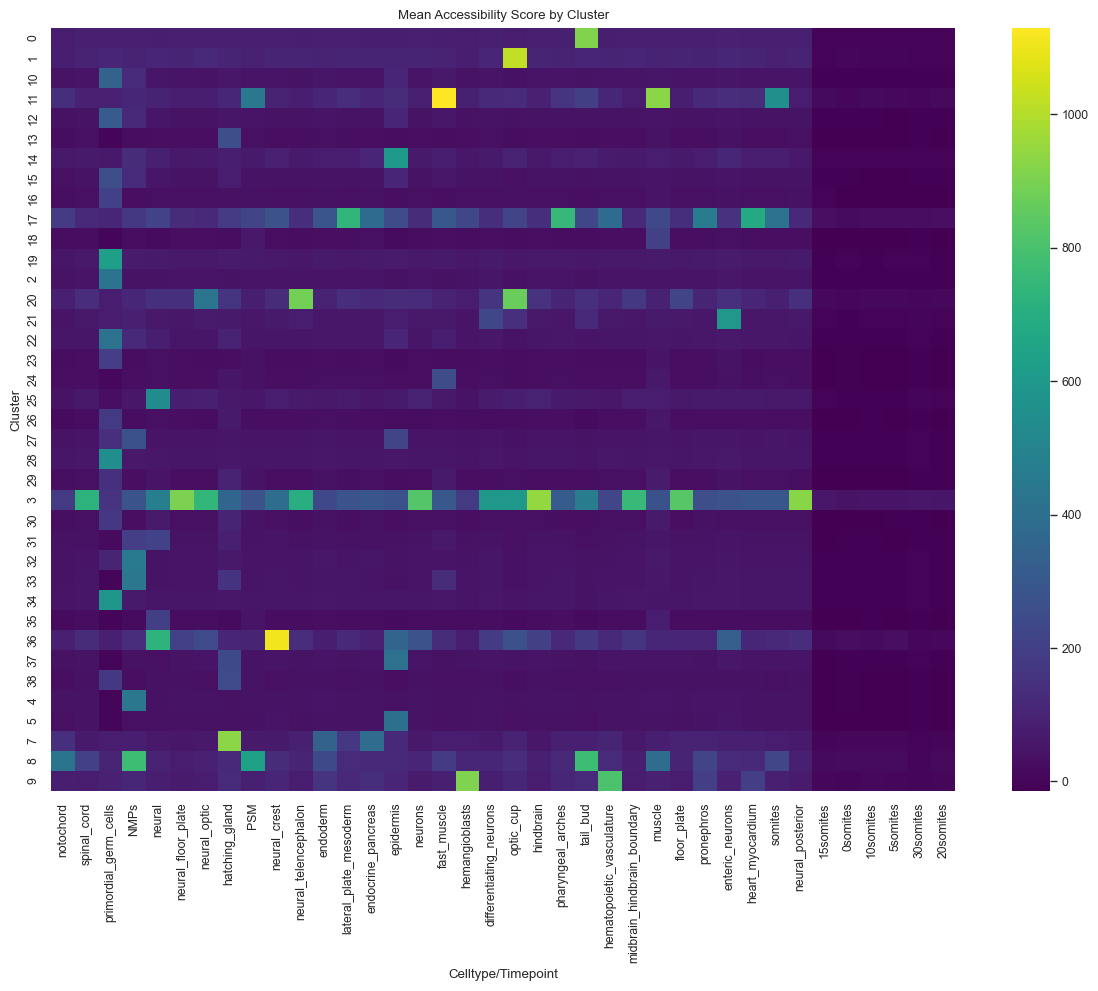

In [51]:
# 2. Aggregate by celltype (using normalized counts)
print("Aggregating accessibility by celltype...")
peaks_pb_hvp_50k = aggregate_accessibility(
    peaks_pb_hvp_50k,
    layer='normalized',  # Use normalized counts
    aggregate_by='celltype',
    store_in_obs=True
)

# 3. Plot accessibility by cluster
fig = plot_accessibility_by_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    sort_celltypes=False,
)
fig

# 4. Create a heatmap comparing clusters by accessibility patterns
fig_heatmap, df_means = compare_clusters_by_accessibility(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_'
)
fig_heatmap

# Optionally, aggregate by timepoint as well
# print("\nAggregating accessibility by timepoint...")
# peaks_pb_hvp_50k = aggregate_accessibility(
#     peaks_pb_hvp_50k,
#     layer='normalized',
#     aggregate_by='timepoint',
#     store_in_obs=True
# )

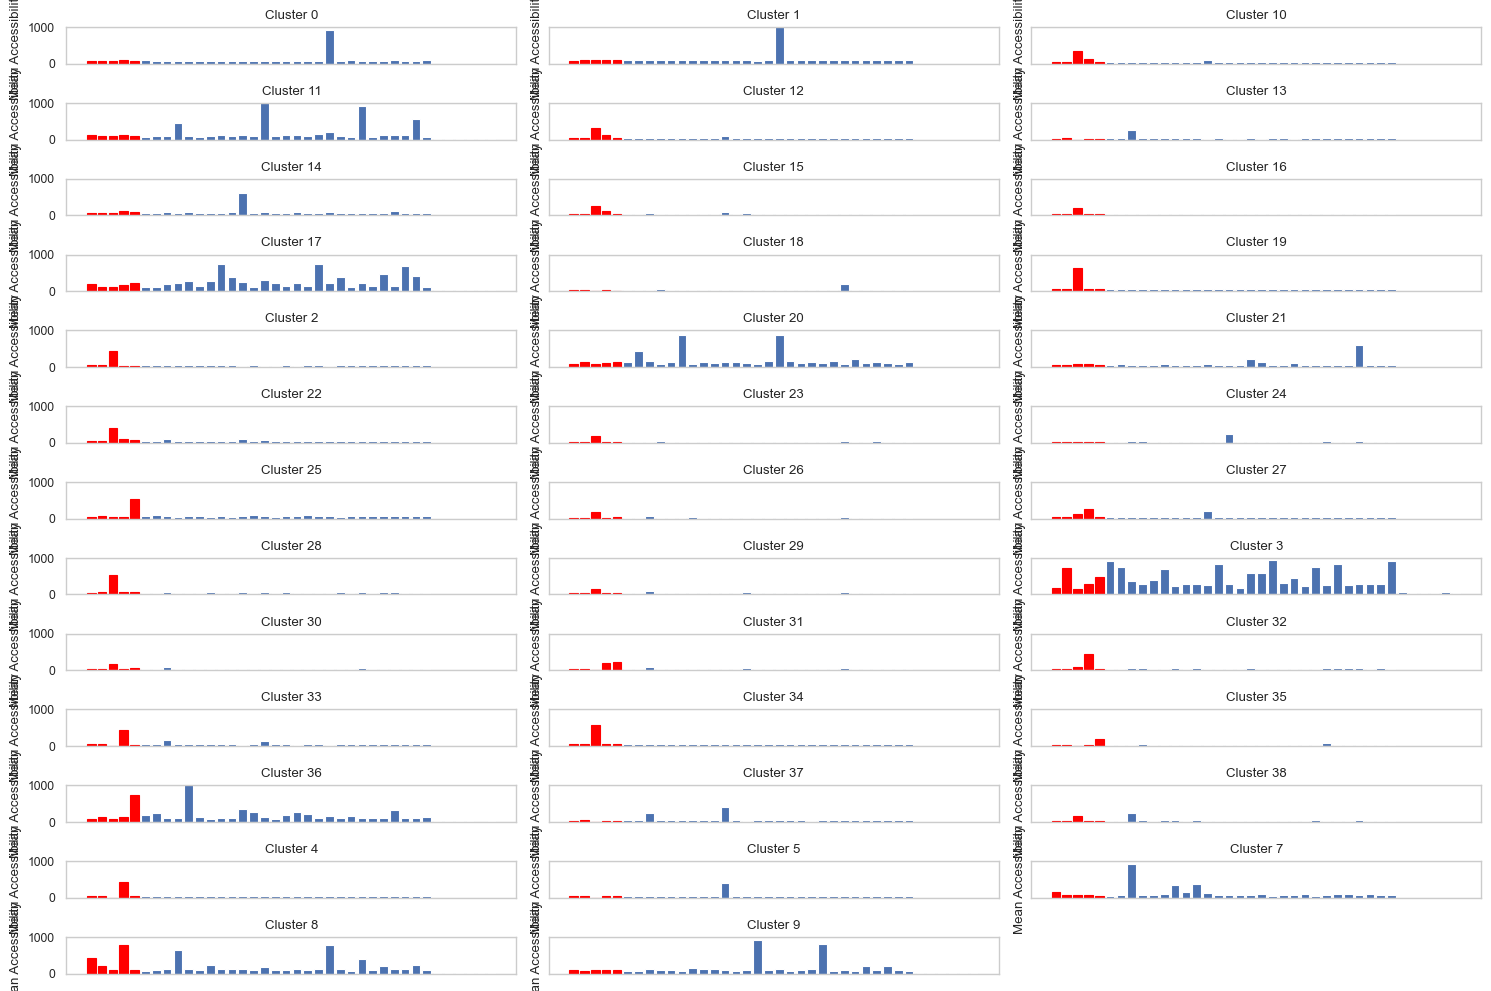

In [53]:
fig

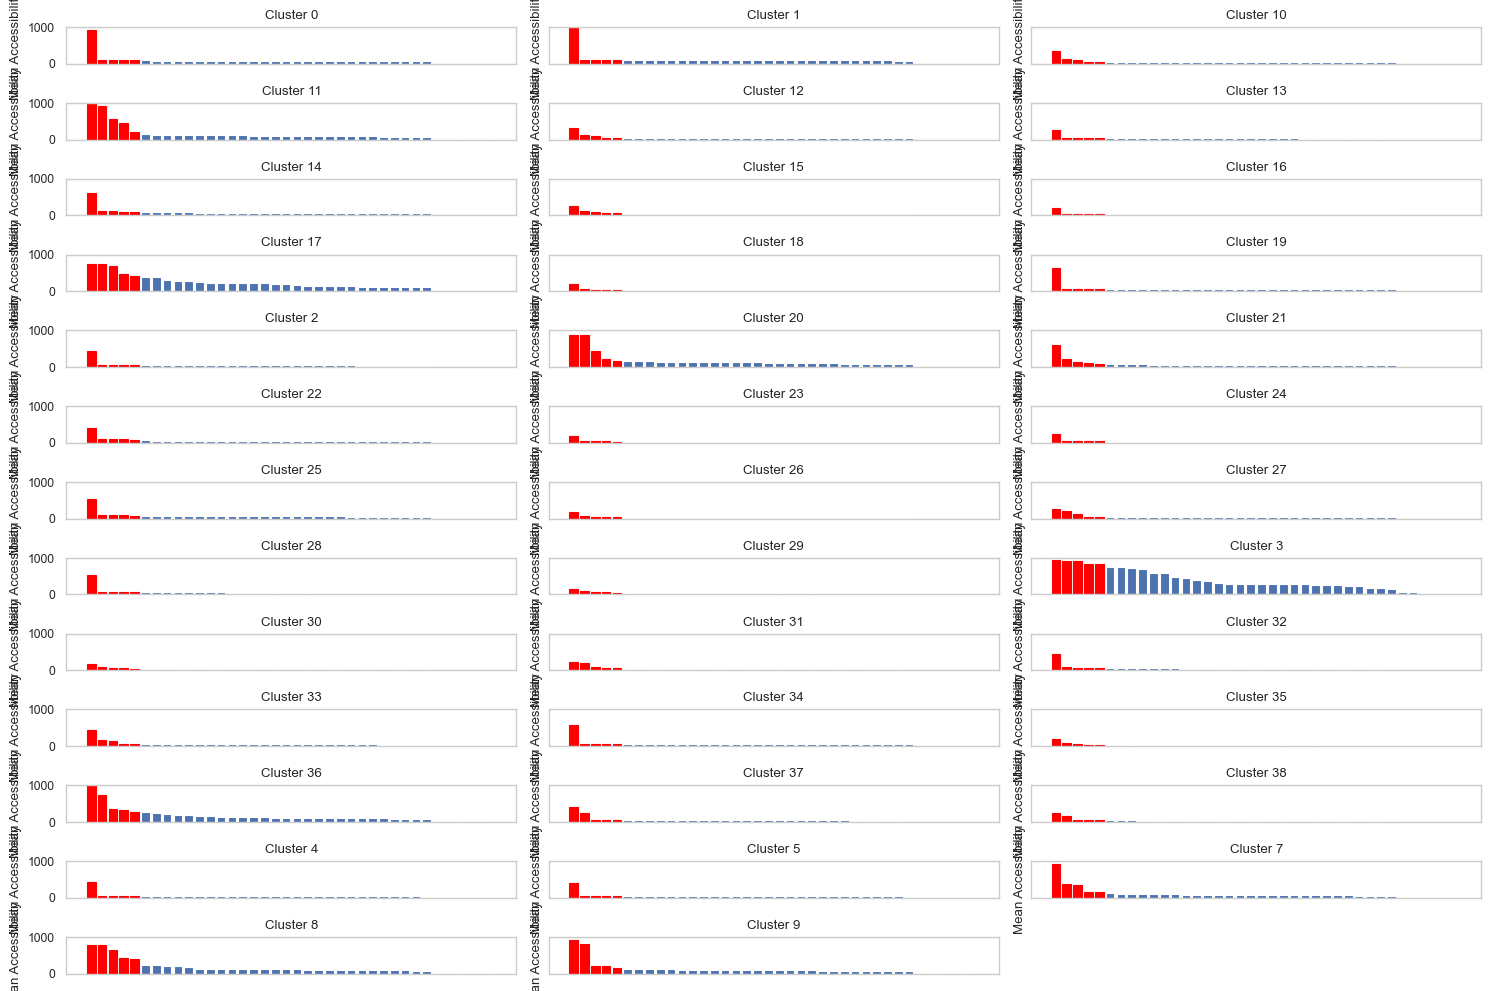

In [43]:
# 3. Plot accessibility by cluster
fig = plot_accessibility_by_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_'
)

fig

In [66]:
def plot_cluster_celltype_grid(adata, 
                              cluster_key='leiden', 
                              accessibility_prefix='accessibility_',
                              exclude_patterns=None,
                              n_top=3,
                              y_max=1000,
                              figsize=None,
                              sort_celltypes='global',
                              highlight_color='red'):
    """
    Create a grid of barplots where each row is a cluster and each plot shows
    accessibility scores across celltypes.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with accessibility scores in obs
    cluster_key : str
        Key in adata.obs for cluster assignments
    accessibility_prefix : str
        Prefix for accessibility columns in adata.obs
    exclude_patterns : list
        List of patterns to exclude from accessibility columns
    n_top : int
        Number of top celltypes to highlight for each cluster
    y_max : int or None
        Maximum value for y-axis. If None, each plot uses its own scale
    figsize : tuple
        Figure size (width, height). If None, automatically calculated
    sort_celltypes : str
        How to sort celltypes:
        - 'global': Sort by overall mean accessibility across all clusters (consistent order)
        - 'cluster': Sort each cluster independently (different order per cluster)
        - 'none': Use original order with no sorting
    highlight_color : str
        Color to use for top celltypes
        
    Returns:
    --------
    fig : matplotlib Figure
    df_means : DataFrame
        Mean accessibility scores by cluster and celltype
    """
    # Get accessibility columns, excluding specified patterns
    accessibility_cols = [col for col in adata.obs.columns 
                         if col.startswith(accessibility_prefix)]
    
    if exclude_patterns:
        for pattern in exclude_patterns:
            accessibility_cols = [col for col in accessibility_cols 
                                 if pattern not in col]
    
    if not accessibility_cols:
        raise ValueError(f"No valid accessibility columns found after filtering.")
    
    # Extract celltype names from column names
    celltypes = [col.replace(accessibility_prefix, '') for col in accessibility_cols]
    
    # Get unique clusters and sort them
    clusters = sorted(adata.obs[cluster_key].unique())
    n_clusters = len(clusters)
    
    # Create a dataframe to store mean accessibility values
    df_means = pd.DataFrame(index=clusters, columns=celltypes)
    
    # Calculate mean accessibility for each cluster and celltype
    for cluster in clusters:
        cluster_mask = adata.obs[cluster_key] == cluster
        for i, col in enumerate(accessibility_cols):
            celltype = celltypes[i]
            # Convert to numeric and calculate mean
            values = pd.to_numeric(adata.obs.loc[cluster_mask, col], errors='coerce')
            df_means.loc[cluster, celltype] = values.mean()
    
    # Identify top celltypes for each cluster
    top_celltypes = {}
    for cluster in clusters:
        # Sort celltypes by accessibility for this cluster
        cluster_values = df_means.loc[cluster].sort_values(ascending=False)
        # Get top n celltypes
        top_celltypes[cluster] = cluster_values.index[:n_top].tolist()
    
    # Sort celltypes based on the sort_celltypes parameter
    if sort_celltypes == 'global':
        # Sort by overall mean accessibility across all clusters
        overall_means = df_means.mean()
        sorted_celltypes = overall_means.sort_values(ascending=False).index.tolist()
    elif sort_celltypes == 'cluster':
        # Use original order of celltypes, each cluster will sort independently
        sorted_celltypes = celltypes
    elif sort_celltypes == 'none':
        # Use original order with no sorting
        sorted_celltypes = celltypes
    else:
        # Default to global sorting if value is unrecognized
        overall_means = df_means.mean()
        sorted_celltypes = overall_means.sort_values(ascending=False).index.tolist()
    
    # Calculate figure size if not provided
    if figsize is None:
        # More compact figure size - reduced width and height
        figsize = (min(15, len(sorted_celltypes) * 0.3), n_clusters * 1.2)  # Much more compact
    
    # Create figure with one row per cluster and minimal spacing
    fig, axs = plt.subplots(n_clusters, 1, figsize=figsize, sharex=True, constrained_layout=False)
    plt.subplots_adjust(hspace=0.1)  # Reduce vertical space between subplots
    
    # If only one cluster, axs won't be an array
    if n_clusters == 1:
        axs = [axs]
    
    # Plot each cluster
    for i, cluster in enumerate(clusters):
        ax = axs[i]
        
        # Get data for this cluster
        if sort_celltypes == 'cluster':
            # Sort celltypes specifically for this cluster
            cluster_values = df_means.loc[cluster].sort_values(ascending=False)
            cluster_celltypes = cluster_values.index.tolist()
            data = cluster_values.values
            
            # Create the barplot with cluster-specific ordering
            bars = ax.bar(range(len(cluster_celltypes)), data)
            
            # Highlight top celltypes (which will be the first n_top bars)
            for j in range(min(n_top, len(bars))):
                bars[j].set_color(highlight_color)
                
            # Set labels for the bottom plot with small font
            if i == n_clusters - 1:
                ax.set_xticks(range(len(cluster_celltypes)))
                ax.set_xticklabels(cluster_celltypes, rotation=90, fontsize=7)  # Smaller font
        else:
            # Use the global or unsorted order
            data = [df_means.loc[cluster, ct] for ct in sorted_celltypes]
            
            # Create the barplot with consistent ordering
            bars = ax.bar(range(len(sorted_celltypes)), data)
            
            # Highlight top celltypes
            for j, celltype in enumerate(sorted_celltypes):
                if celltype in top_celltypes[cluster]:
                    bars[j].set_color(highlight_color)
                    
            # Set labels for the bottom plot with small font
            if i == n_clusters - 1:
                ax.set_xticks(range(len(sorted_celltypes)))
                ax.set_xticklabels(sorted_celltypes, rotation=90, fontsize=7)  # Smaller font
        
        # Set title (cluster ID) without additional y-axis label
        ax.set_title(f'Cluster {cluster}', loc='left')
        
        # Remove y-axis label
        ax.set_ylabel('')
        
        # Set y-axis limit if specified
        if y_max is not None:
            ax.set_ylim(0, y_max)
            
        # Remove grid
        ax.grid(False)
        
        # Compress y-axis by setting very tight y margins
        ax.margins(y=0.02)
        
        # Reduce the height of the bars to make them more compact
        if isinstance(bars, list) or isinstance(bars, np.ndarray):
            for bar in bars:
                bar.set_height(bar.get_height() * 0.85)  # Make bars slightly shorter
        
        # Make the subplot more compact vertically
        ax.set_title(f'Cluster {cluster}', loc='left', fontsize=9, pad=2)  # Smaller title with less padding
        
        # Only show x-tick labels on the bottom plot
        if i == n_clusters - 1:
            ax.set_xticks(range(len(sorted_celltypes)))
            ax.set_xticklabels(sorted_celltypes, rotation=90)
        else:
            ax.set_xticks([])
    
    plt.tight_layout()
    return fig, df_means

def print_cluster_top_celltypes(df_means, n_top=3):
    """
    Print the top celltypes for each cluster.
    
    Parameters:
    -----------
    df_means : DataFrame
        DataFrame with clusters as rows and celltypes as columns
    n_top : int
        Number of top celltypes to print
        
    Returns:
    --------
    None
    """
    for cluster in df_means.index:
        # Sort celltypes by accessibility for this cluster
        cluster_values = df_means.loc[cluster].sort_values(ascending=False)
        # Get top n celltypes and their values
        top_n = cluster_values.iloc[:n_top]
        
        # Format output
        top_str = ", ".join([f"{ct} ({val:.2f})" for ct, val in top_n.items()])
        print(f"Cluster {cluster}: {top_str}")

In [67]:
# Define timepoint patterns to exclude
timepoint_patterns = [
    'accessibility_15somites',
    'accessibility_0somites', 
    'accessibility_10somites', 
    'accessibility_5somites', 
    'accessibility_30somites', 
    'accessibility_20somites'
]

# Create the extremely compact plot
fig, df_means = plot_cluster_celltype_grid(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    exclude_patterns=timepoint_patterns,
    n_top=3,
    y_max=1000,
    sort_celltypes='global'  # Use consistent ordering across all clusters
)

# Optional: Adjust bottom margin to ensure x-axis labels are visible
plt.subplots_adjust(bottom=0.15)

# Save the figure with high DPI
fig.savefig('cluster_celltype_accessibility.pdf', dpi=600, bbox_inches='tight')

# # Print top celltypes for reference
# print_cluster_top_celltypes(df_means, n_top=3)

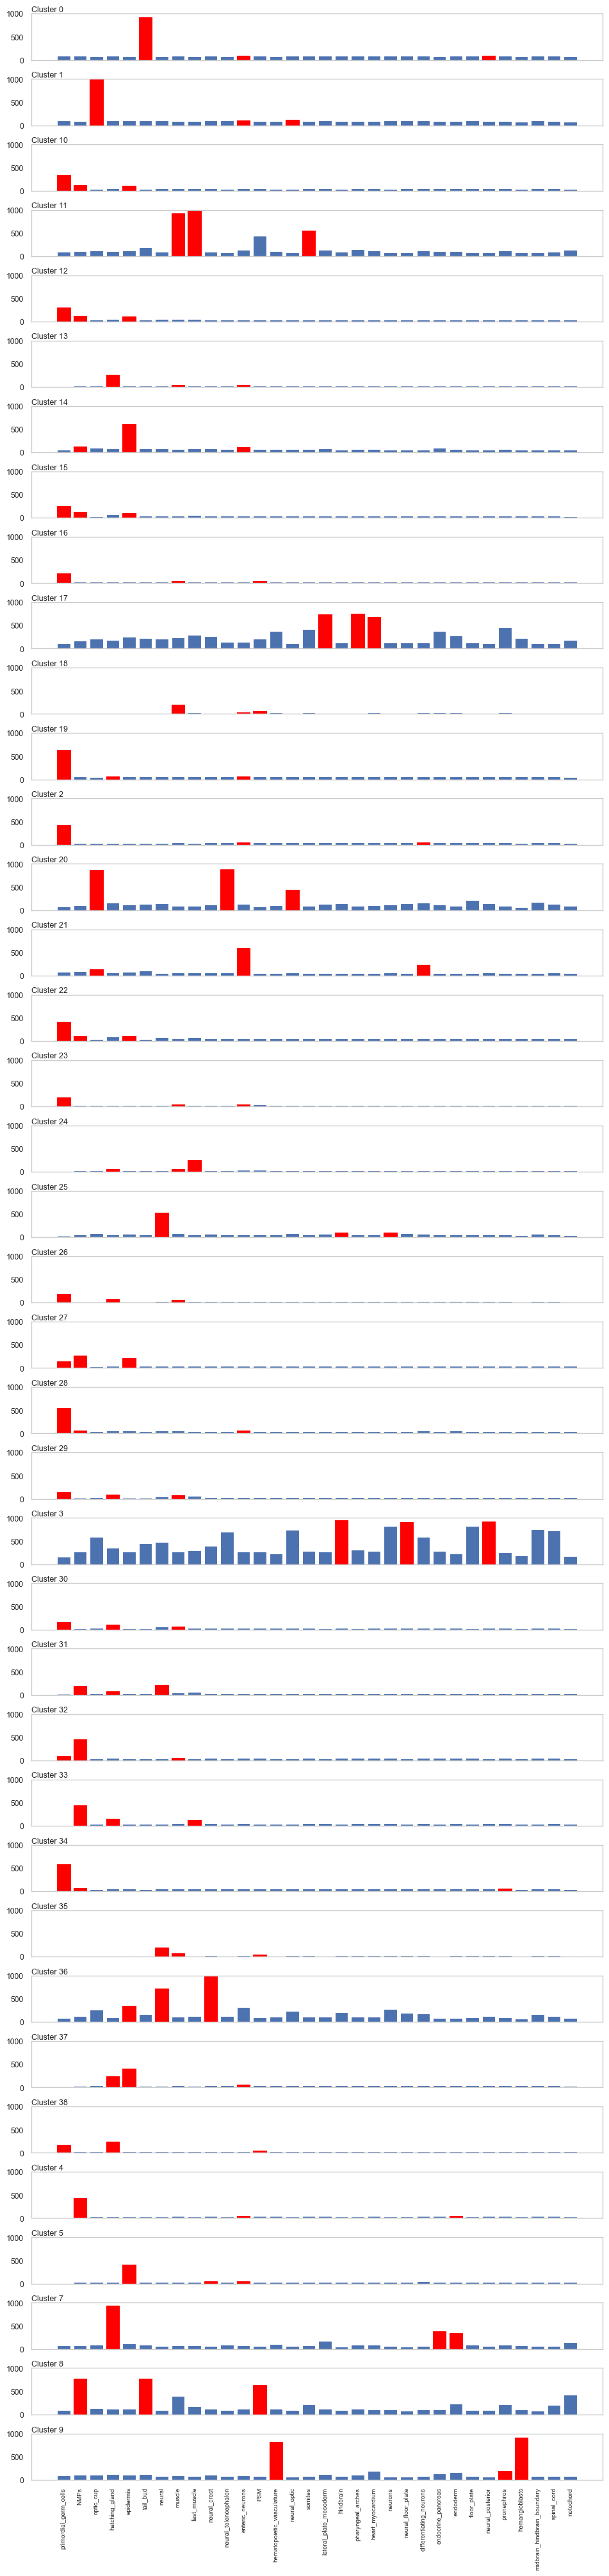

In [69]:
fig

In [57]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.multitest as multi

def test_celltype_enrichment(adata, 
                           cluster_key='leiden', 
                           accessibility_prefix='accessibility_',
                           exclude_patterns=None,
                           alpha=0.05,
                           correction_method='fdr_bh'):
    """
    Perform statistical tests to determine if certain celltypes are significantly 
    enriched in each cluster.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with accessibility scores in obs
    cluster_key : str
        Key in adata.obs for cluster assignments
    accessibility_prefix : str
        Prefix for accessibility columns in adata.obs
    exclude_patterns : list
        List of patterns to exclude from accessibility columns
    alpha : float
        Significance level for multiple testing correction
    correction_method : str
        Method for multiple testing correction (options: 'bonferroni', 'fdr_bh', etc.)
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame with enrichment test results
    """
    # Get accessibility columns, excluding specified patterns
    accessibility_cols = [col for col in adata.obs.columns 
                         if col.startswith(accessibility_prefix)]
    
    if exclude_patterns:
        for pattern in exclude_patterns:
            accessibility_cols = [col for col in accessibility_cols 
                                 if pattern not in col]
    
    if not accessibility_cols:
        raise ValueError(f"No valid accessibility columns found after filtering.")
    
    # Extract celltype names from column names
    celltypes = [col.replace(accessibility_prefix, '') for col in accessibility_cols]
    
    # Get unique clusters and sort them
    clusters = sorted(adata.obs[cluster_key].unique())
    
    # Prepare results data
    results = []
    
    # For each cluster, test if its accessibility for each celltype is higher than other clusters
    for celltype, access_col in zip(celltypes, accessibility_cols):
        for cluster in clusters:
            # Split data into this cluster vs other clusters
            mask_cluster = adata.obs[cluster_key] == cluster
            
            # Get accessibility values
            values_cluster = pd.to_numeric(adata.obs.loc[mask_cluster, access_col], errors='coerce')
            values_other = pd.to_numeric(adata.obs.loc[~mask_cluster, access_col], errors='coerce')
            
            # Skip if not enough data
            if len(values_cluster) < 5 or len(values_other) < 5:
                continue
            
            # Calculate means for reporting
            mean_cluster = values_cluster.mean()
            mean_other = values_other.mean()
            fold_change = mean_cluster / mean_other if mean_other > 0 else float('inf')
            
            # 1. Mann-Whitney U Test (non-parametric, robust to non-normal data)
            try:
                u_stat, p_value_mw = stats.mannwhitneyu(
                    values_cluster.dropna(), 
                    values_other.dropna(), 
                    alternative='greater'  # Test if cluster values are greater
                )
            except:
                p_value_mw = 1.0
            
            # 2. t-test (parametric, assumes normal distribution)
            try:
                t_stat, p_value_t = stats.ttest_ind(
                    values_cluster.dropna(), 
                    values_other.dropna(), 
                    equal_var=False,  # Use Welch's t-test (doesn't assume equal variance)
                    alternative='greater'  # Test if cluster values are greater
                )
            except:
                p_value_t = 1.0
            
            # 3. Calculate effect size (Cohen's d)
            try:
                s1 = values_cluster.std()
                s2 = values_other.std()
                n1 = len(values_cluster)
                n2 = len(values_other)
                
                # Pooled standard deviation
                s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
                
                # Cohen's d
                cohens_d = (mean_cluster - mean_other) / s_pooled if s_pooled > 0 else 0
            except:
                cohens_d = 0
            
            # Store results
            results.append({
                'cluster': cluster,
                'celltype': celltype,
                'mean_accessibility_cluster': mean_cluster,
                'mean_accessibility_other': mean_other,
                'fold_change': fold_change,
                'p_value_mannwhitney': p_value_mw,
                'p_value_ttest': p_value_t,
                'effect_size_cohens_d': cohens_d
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Apply multiple testing correction
    if not results_df.empty:
        # Correct p-values for each test separately
        results_df['p_adj_mannwhitney'] = multi.multipletests(
            results_df['p_value_mannwhitney'], 
            alpha=alpha, 
            method=correction_method
        )[1]
        
        results_df['p_adj_ttest'] = multi.multipletests(
            results_df['p_value_ttest'], 
            alpha=alpha, 
            method=correction_method
        )[1]
        
        # Add significance indicators
        results_df['significant_mannwhitney'] = results_df['p_adj_mannwhitney'] < alpha
        results_df['significant_ttest'] = results_df['p_adj_ttest'] < alpha
    
    return results_df

def plot_celltype_enrichment_heatmap(results_df, 
                                   top_n=3, 
                                   p_value_col='p_adj_mannwhitney',
                                   value_col='fold_change',
                                   figsize=(12, 10)):
    """
    Create a heatmap visualizing celltype enrichment across clusters.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with enrichment test results from test_celltype_enrichment
    top_n : int
        Number of top celltypes to highlight in each cluster
    p_value_col : str
        Column name for p-values to use for significance
    value_col : str
        Column name for values to display in heatmap (e.g., 'fold_change', 'effect_size_cohens_d')
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig : matplotlib Figure
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Filter for significant results
    sig_results = results_df[results_df[p_value_col] < 0.05].copy()
    
    if sig_results.empty:
        print("No significant enrichments found.")
        return None
    
    # Create pivot table for heatmap
    pivot_data = sig_results.pivot_table(
        index='cluster', 
        columns='celltype', 
        values=value_col,
        fill_value=0
    )
    
    # Find top celltypes for each cluster
    top_celltypes = {}
    for cluster in pivot_data.index:
        cluster_data = pivot_data.loc[cluster].sort_values(ascending=False)
        top_celltypes[cluster] = cluster_data.index[:top_n].tolist()
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create mask for non-significant values
    mask = pivot_data == 0
    
    # Create heatmap
    sns.heatmap(
        pivot_data,
        cmap='viridis',
        mask=mask,
        annot=True,
        fmt='.1f',
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'Significant Celltype Enrichment (values: {value_col})')
    ax.set_xlabel('Celltype')
    ax.set_ylabel('Cluster')
    
    plt.tight_layout()
    return fig, pivot_data

def get_top_enriched_celltypes(results_df, 
                              n_top=3, 
                              p_value_col='p_adj_mannwhitney',
                              value_col='fold_change',
                              alpha=0.05):
    """
    Get the top significantly enriched celltypes for each cluster.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with enrichment test results
    n_top : int
        Number of top celltypes to return for each cluster
    p_value_col : str
        Column name for adjusted p-values
    value_col : str
        Column name for values to sort by (e.g., 'fold_change', 'effect_size_cohens_d')
    alpha : float
        Significance threshold
        
    Returns:
    --------
    top_celltypes : dict
        Dictionary mapping clusters to lists of (celltype, value, p-value) tuples
    """
    # Filter for significant results
    sig_results = results_df[results_df[p_value_col] < alpha].copy()
    
    if sig_results.empty:
        print("No significant enrichments found.")
        return {}
    
    # Get unique clusters
    clusters = sig_results['cluster'].unique()
    
    # Dictionary to store results
    top_celltypes = {}
    
    # For each cluster, find top celltypes
    for cluster in clusters:
        cluster_data = sig_results[sig_results['cluster'] == cluster]
        
        # Sort by the specified value column
        sorted_data = cluster_data.sort_values(value_col, ascending=False)
        
        # Get top n celltypes
        top_celltypes[cluster] = [
            (row['celltype'], row[value_col], row[p_value_col]) 
            for _, row in sorted_data.head(n_top).iterrows()
        ]
    
    return top_celltypes

# Example usage:
"""
# Define timepoint patterns to exclude
timepoint_patterns = [
    'accessibility_15somites',
    'accessibility_0somites', 
    'accessibility_10somites', 
    'accessibility_5somites', 
    'accessibility_30somites', 
    'accessibility_20somites'
]

# 1. Run statistical tests
enrichment_results = test_celltype_enrichment(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    exclude_patterns=timepoint_patterns,
    alpha=0.05,
    correction_method='fdr_bh'  # Benjamini-Hochberg FDR correction
)

# 2. Get top enriched celltypes
top_enriched = get_top_enriched_celltypes(
    enrichment_results,
    n_top=3,
    p_value_col='p_adj_mannwhitney',  # Use Mann-Whitney test (non-parametric)
    value_col='fold_change',  # Sort by fold change
    alpha=0.05
)

# 3. Print results
print("Top significantly enriched celltypes by cluster:")
for cluster, celltypes in top_enriched.items():
    celltype_str = ", ".join([f"{ct} (FC={fc:.2f}, p={p:.1e})" for ct, fc, p in celltypes])
    print(f"Cluster {cluster}: {celltype_str}")

# 4. Visualize as heatmap
fig, pivot_data = plot_celltype_enrichment_heatmap(
    enrichment_results,
    top_n=3,
    p_value_col='p_adj_mannwhitney',
    value_col='fold_change',
    figsize=(12, 10)
)
"""

'\n# Define timepoint patterns to exclude\ntimepoint_patterns = [\n    \'accessibility_15somites\',\n    \'accessibility_0somites\', \n    \'accessibility_10somites\', \n    \'accessibility_5somites\', \n    \'accessibility_30somites\', \n    \'accessibility_20somites\'\n]\n\n# 1. Run statistical tests\nenrichment_results = test_celltype_enrichment(\n    peaks_pb_hvp_50k,\n    cluster_key=\'leiden\',\n    accessibility_prefix=\'accessibility_\',\n    exclude_patterns=timepoint_patterns,\n    alpha=0.05,\n    correction_method=\'fdr_bh\'  # Benjamini-Hochberg FDR correction\n)\n\n# 2. Get top enriched celltypes\ntop_enriched = get_top_enriched_celltypes(\n    enrichment_results,\n    n_top=3,\n    p_value_col=\'p_adj_mannwhitney\',  # Use Mann-Whitney test (non-parametric)\n    value_col=\'fold_change\',  # Sort by fold change\n    alpha=0.05\n)\n\n# 3. Print results\nprint("Top significantly enriched celltypes by cluster:")\nfor cluster, celltypes in top_enriched.items():\n    celltype

In [58]:
# Run statistical tests
enrichment_results = test_celltype_enrichment(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    exclude_patterns=timepoint_patterns,
    alpha=0.05,
    correction_method='fdr_bh'  # Benjamini-Hochberg FDR correction
)

# Get top enriched celltypes
top_enriched = get_top_enriched_celltypes(
    enrichment_results,
    n_top=3,
    p_value_col='p_adj_mannwhitney',  # Use Mann-Whitney test (non-parametric)
    value_col='fold_change',  # Sort by fold change
    alpha=0.05
)

# Print results
print("Top significantly enriched celltypes by cluster:")
for cluster, celltypes in top_enriched.items():
    celltype_str = ", ".join([f"{ct} (FC={fc:.2f}, p={p:.1e})" for ct, fc, p in celltypes])
    print(f"Cluster {cluster}: {celltype_str}")

# Visualize as heatmap
fig, pivot_data = plot_celltype_enrichment_heatmap(
    enrichment_results,
    p_value_col='p_adj_mannwhitney',
    value_col='fold_change'
)

Top significantly enriched celltypes by cluster:
Cluster 0: tail_bud (FC=7.19, p=0.0e+00), enteric_neurons (FC=0.92, p=2.8e-66), neural_crest (FC=0.89, p=1.4e-235)
Cluster 1: optic_cup (FC=8.83, p=0.0e+00), enteric_neurons (FC=1.13, p=7.7e-267), neural_crest (FC=1.11, p=0.0e+00)
Cluster 11: fast_muscle (FC=12.59, p=0.0e+00), muscle (FC=9.40, p=0.0e+00), somites (FC=6.26, p=0.0e+00)
Cluster 17: pharyngeal_arches (FC=9.08, p=0.0e+00), lateral_plate_mesoderm (FC=8.63, p=0.0e+00), heart_myocardium (FC=8.16, p=0.0e+00)
Cluster 20: neural_telencephalon (FC=8.71, p=5.4e-302), neural_optic (FC=4.12, p=1.2e-308), optic_cup (FC=3.64, p=4.2e-232)
Cluster 3: hindbrain (FC=14.11, p=0.0e+00), neural_posterior (FC=14.08, p=0.0e+00), neural_floor_plate (FC=13.73, p=0.0e+00)
Cluster 36: neural_crest (FC=12.24, p=1.4e-70), neural (FC=7.26, p=1.3e-55), enteric_neurons (FC=3.38, p=2.7e-37)
Cluster 7: hatching_gland (FC=9.28, p=0.0e+00), endocrine_pancreas (FC=4.41, p=0.0e+00), endoderm (FC=3.92, p=6.1e-25

In [71]:
def create_biologically_ordered_celltypes(celltypes):
    """
    Create a biologically meaningful ordering of celltypes, grouping related cell types together.
    
    Parameters:
    -----------
    celltypes : list
        List of cell type names to be ordered
    
    Returns:
    --------
    ordered_celltypes : list
        Ordered list of cell types
    """
    # Define groups of related cell types
    cell_type_groups = {
        # Neural lineage
        'neural': [
            'neural', 'neurons', 'neural_crest', 'neural_plate', 'neural_floor_plate', 
            'neural_optic', 'neural_telencephalon', 'neural_posterior', 'optic_cup',
            'hindbrain', 'midbrain_hindbrain_boundary', 'differentiating_neurons',
            'enteric_neurons'
        ],
        
        # Mesoderm/hematopoietic lineage
        'mesoderm_hematopoietic': [
            'hemangioblasts', 'hematopoietic_vasculature', 'somites', 'heart_myocardium',
            'heart', 'lateral_plate_mesoderm', 'mesoderm', 'muscle', 'fast_muscle',
            '5somites', '10somites', '15somites', '20somites', '30somites', '0somites'
        ],
        
        # Endodermal lineage
        'endoderm': [
            'endoderm', 'endocrine_pancreas', 'pancreas', 'pronephros'
        ],
        
        # Ectodermal/epidermal lineage
        'ectoderm': [
            'epidermis', 'hatching_gland', 'ectoderm'
        ],
        
        # Primordial/stem cell lineage
        'primordial': [
            'primordial_germ_cells', 'PSM', 'notochord', 'tail_bud', 'floor_plate'
        ],
        
        # Other/miscellaneous
        'other': [
            'NMPs', 'spinal_cord', 'pharyngeal_arches', 'gene_body_overlaps'
        ]
    }
    
    # Create a flattened list of ordered celltypes across all groups
    ordered_groups = ['neural', 'mesoderm_hematopoietic', 'endoderm', 'ectoderm', 'primordial', 'other']
    ordered_celltypes = []
    
    # Track which celltypes have been added
    added_celltypes = set()
    
    # First pass: Add celltypes that match our predefined groups
    for group in ordered_groups:
        for celltype_pattern in cell_type_groups[group]:
            # Find all matching celltypes that contain this pattern
            matching_celltypes = [ct for ct in celltypes 
                                if celltype_pattern in ct and ct not in added_celltypes]
            
            # Sort matching celltypes alphabetically for consistent ordering
            matching_celltypes.sort()
            
            # Add them to the ordered list
            ordered_celltypes.extend(matching_celltypes)
            added_celltypes.update(matching_celltypes)
    
    # Second pass: Add any remaining celltypes that weren't matched
    remaining_celltypes = [ct for ct in celltypes if ct not in added_celltypes]
    ordered_celltypes.extend(sorted(remaining_celltypes))
    
    return ordered_celltypes

def update_cluster_celltype_grid_with_custom_ordering(plot_cluster_celltype_grid_func):
    """
    Wrapper function to add biologically meaningful ordering to the existing
    plot_cluster_celltype_grid function.
    
    Parameters:
    -----------
    plot_cluster_celltype_grid_func : function
        The original plotting function
    
    Returns:
    --------
    wrapped_function : function
        Updated function with biological ordering option
    """
    def wrapped_function(adata, 
                        cluster_key='leiden', 
                        accessibility_prefix='accessibility_',
                        exclude_patterns=None,
                        n_top=3,
                        y_max=1000,
                        figsize=None,
                        sort_celltypes='global',
                        highlight_color='red',
                        use_biological_ordering=False):
        """
        Create a grid of barplots with optional biological ordering of celltypes.
        
        Parameters:
        -----------
        [original parameters...]
        use_biological_ordering : bool
            Whether to use biological grouping for celltype ordering
        """
        # Get all accessibility columns, excluding specified patterns
        accessibility_cols = [col for col in adata.obs.columns 
                             if col.startswith(accessibility_prefix)]
        
        if exclude_patterns:
            for pattern in exclude_patterns:
                accessibility_cols = [col for col in accessibility_cols 
                                     if pattern not in col]
        
        if not accessibility_cols:
            raise ValueError(f"No valid accessibility columns found after filtering.")
        
        # Extract celltype names from column names
        celltypes = [col.replace(accessibility_prefix, '') for col in accessibility_cols]
        
        # Apply biological ordering if requested
        if use_biological_ordering:
            # Create biologically ordered celltype list
            ordered_celltypes = create_biologically_ordered_celltypes(celltypes)
            
            # Override sort_celltypes parameter
            sort_celltypes = 'custom'
            
            # Create a mapping from original celltypes to ordered ones
            celltype_to_ordered = {ct: idx for idx, ct in enumerate(ordered_celltypes)}
            
            # Call the original function with custom sorting
            fig, df_means = plot_cluster_celltype_grid_func(
                adata=adata,
                cluster_key=cluster_key,
                accessibility_prefix=accessibility_prefix,
                exclude_patterns=exclude_patterns,
                n_top=n_top,
                y_max=y_max,
                figsize=figsize,
                sort_celltypes='none',  # Will override with our custom order
                highlight_color=highlight_color
            )
            
            # For each subplot, reorder the x-axis according to our biological grouping
            for i, ax in enumerate(fig.axes):
                if i < len(adata.obs[cluster_key].unique()):
                    # Get the current bars
                    bars = ax.patches
                    
                    # Only proceed if we have the right number of bars
                    if len(bars) == len(celltypes):
                        # Get current values and colors
                        heights = [bar.get_height() for bar in bars]
                        colors = [bar.get_facecolor() for bar in bars]
                        
                        # Create new bars in the biologically ordered sequence
                        ax.clear()
                        new_bars = ax.bar(
                            range(len(ordered_celltypes)),
                            [heights[celltypes.index(ct)] for ct in ordered_celltypes],
                            color=[colors[celltypes.index(ct)] for ct in ordered_celltypes]
                        )
                        
                        # Set x-axis labels for the bottom plot
                        if i == len(adata.obs[cluster_key].unique()) - 1:
                            ax.set_xticks(range(len(ordered_celltypes)))
                            ax.set_xticklabels(ordered_celltypes, rotation=90, fontsize=7)
                        
                        # Apply other formatting (from the original function)
                        ax.set_title("", loc='left', fontsize=0, pad=0)
                        ax.set_ylabel(f"{adata.obs[cluster_key].unique()[i]}", fontsize=7, 
                                    rotation=0, ha='right', va='center', labelpad=2)
                        ax.tick_params(axis='y', which='both', left=False, labelleft=True)
                        ax.margins(y=0.01)
                        ax.grid(False)
                        
                        # Only show y-axis tick labels on specific rows
                        if i != 0:
                            yt_labels = [item.get_text() for item in ax.get_yticklabels()]
                            empty_labels = ['' for _ in yt_labels]
                            ax.set_yticklabels(empty_labels)
                            
                        # Only show the value 0 and the max value for the first subplot
                        if i == 0:
                            ax.set_yticks([0, y_max])
                        else:
                            ax.set_yticks([])
            
            return fig, df_means
        else:
            # Just call the original function
            return plot_cluster_celltype_grid_func(
                adata=adata,
                cluster_key=cluster_key,
                accessibility_prefix=accessibility_prefix,
                exclude_patterns=exclude_patterns,
                n_top=n_top,
                y_max=y_max,
                figsize=figsize,
                sort_celltypes=sort_celltypes,
                highlight_color=highlight_color
            )
    
    return wrapped_function

In [72]:
# First, wrap the original function with the biological ordering capability
plot_cluster_celltype_grid_with_ordering = update_cluster_celltype_grid_with_custom_ordering(plot_cluster_celltype_grid)

# Define timepoint patterns to exclude
timepoint_patterns = [
    'accessibility_15somites',
    'accessibility_0somites', 
    'accessibility_10somites', 
    'accessibility_5somites', 
    'accessibility_30somites', 
    'accessibility_20somites'
]

# Create the plot with biological ordering
fig, df_means = plot_cluster_celltype_grid_with_ordering(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    accessibility_prefix='accessibility_',
    exclude_patterns=timepoint_patterns,
    n_top=3,
    y_max=1000,
    use_biological_ordering=True  # Enable biological ordering
)

# Save the figure
plt.tight_layout()
fig.savefig('cluster_celltype_biological_ordering.pdf', dpi=300, bbox_inches='tight')

/tmp/ipykernel_1541021/3227827153.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(empty_labels)
/tmp/ipykernel_1541021/3227827153.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(empty_labels)
/tmp/ipykernel_1541021/3227827153.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(empty_labels)
/tmp/ipykernel_1541021/3227827153.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(empty_labels)
/tmp/ipykernel_1541021/3227827153.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_y

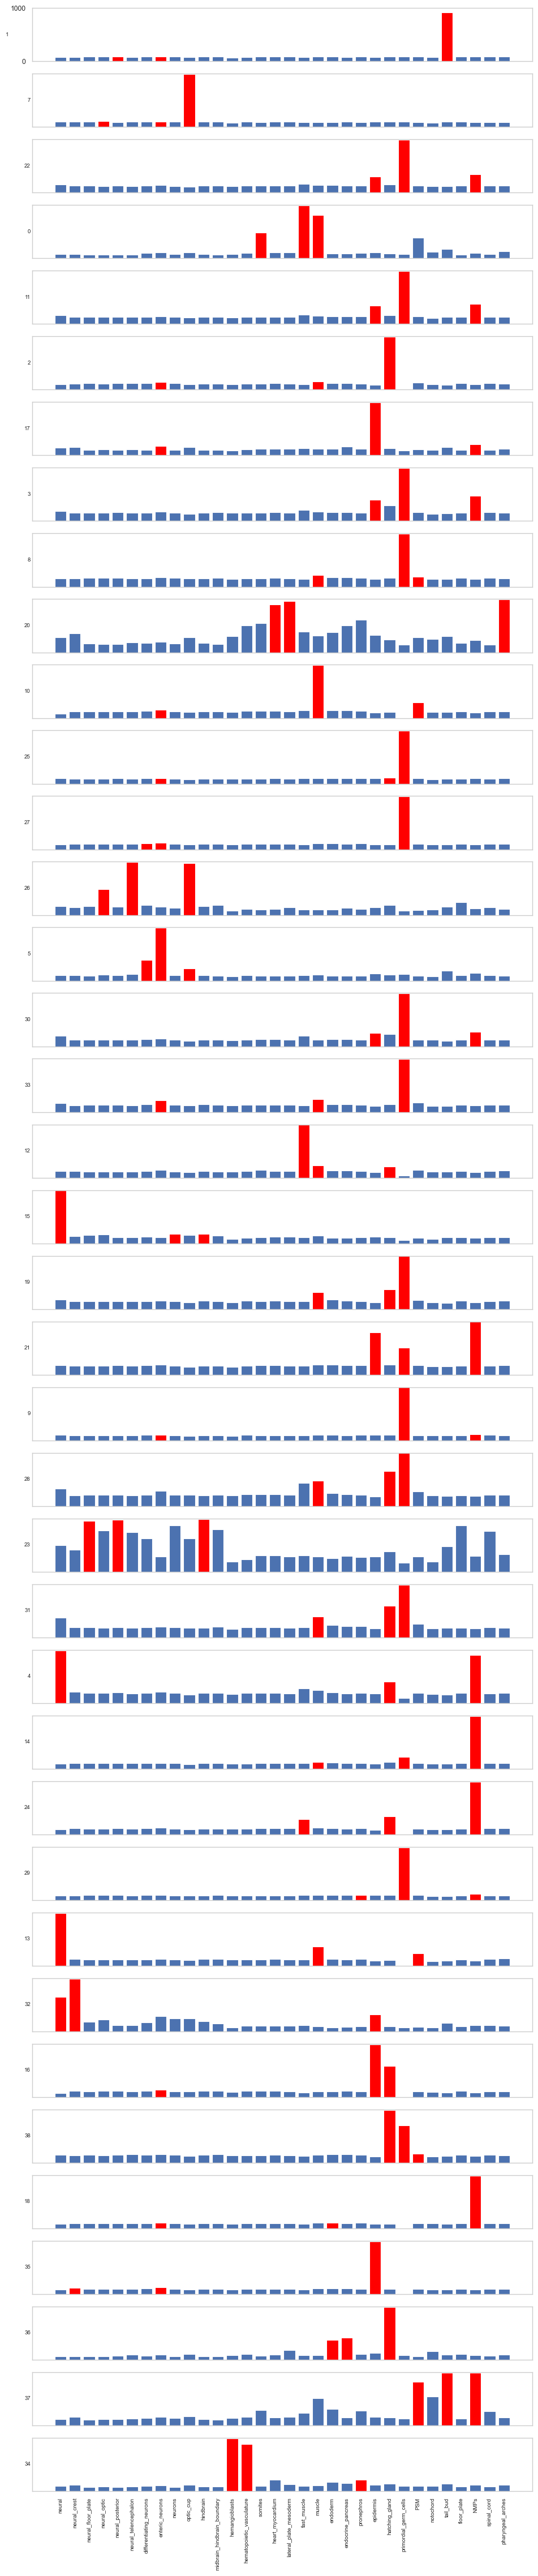

In [73]:
fig

In [74]:
def plot_peaks_per_cluster(adata, 
                          cluster_key='leiden', 
                          figsize=(10, 6), 
                          color='skyblue',
                          highlight_top=3,
                          highlight_color='red',
                          sort_by='count'):
    """
    Create a bar plot showing the number of peaks in each cluster.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with peak data
    cluster_key : str
        Key in adata.obs for cluster assignments
    figsize : tuple
        Figure size (width, height)
    color : str
        Color for regular bars
    highlight_top : int
        Number of top clusters to highlight
    highlight_color : str
        Color for highlighted top clusters
    sort_by : str
        How to sort clusters:
        - 'count': Sort by number of peaks (descending)
        - 'cluster': Sort by cluster ID
        - 'none': Use original order
        
    Returns:
    --------
    fig : matplotlib Figure
    """
    # Count peaks per cluster
    cluster_counts = adata.obs[cluster_key].value_counts()
    
    # Sort values if requested
    if sort_by == 'count':
        cluster_counts = cluster_counts.sort_values(ascending=False)
    elif sort_by == 'cluster':
        # Try to sort numerically if possible, otherwise sort as strings
        try:
            # Convert index to numeric and sort
            numeric_index = pd.to_numeric(cluster_counts.index)
            cluster_counts = cluster_counts.loc[sorted(numeric_index)]
        except:
            # If conversion fails, sort as strings
            cluster_counts = cluster_counts.loc[sorted(cluster_counts.index)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare colors - default is the main color, highlight for top N
    colors = [color] * len(cluster_counts)
    
    # Highlight top clusters if requested
    if highlight_top > 0:
        # Get indices of top clusters by count
        top_indices = cluster_counts.values.argsort()[-highlight_top:]
        
        # Set highlighted color for top clusters
        for idx in top_indices:
            colors[idx] = highlight_color
    
    # Create bar plot
    bars = ax.bar(range(len(cluster_counts)), cluster_counts.values, color=colors)
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1*max(cluster_counts),
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # Set labels and title
    ax.set_xlabel('Cluster ID', fontsize=12)
    ax.set_ylabel('Number of Peaks', fontsize=12)
    ax.set_title('Number of Peaks per Cluster', fontsize=14)
    
    # Set x-tick labels to cluster IDs
    ax.set_xticks(range(len(cluster_counts)))
    ax.set_xticklabels(cluster_counts.index, rotation=45)
    
    # Add grid for easier reading of values
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tight layout
    plt.tight_layout()
    
    return fig, cluster_counts

# Alternative version with horizontal bars - better for many clusters
def plot_peaks_per_cluster_horizontal(adata, 
                                    cluster_key='leiden', 
                                    figsize=(8, 10), 
                                    color='skyblue',
                                    highlight_top=3,
                                    highlight_color='red',
                                    sort_by='count'):
    """
    Create a horizontal bar plot showing the number of peaks in each cluster.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with peak data
    cluster_key : str
        Key in adata.obs for cluster assignments
    figsize : tuple
        Figure size (width, height)
    color : str
        Color for regular bars
    highlight_top : int
        Number of top clusters to highlight
    highlight_color : str
        Color for highlighted top clusters
    sort_by : str
        How to sort clusters:
        - 'count': Sort by number of peaks (descending)
        - 'cluster': Sort by cluster ID
        - 'none': Use original order
        
    Returns:
    --------
    fig : matplotlib Figure
    """
    # Count peaks per cluster
    cluster_counts = adata.obs[cluster_key].value_counts()
    
    # Sort values if requested
    if sort_by == 'count':
        cluster_counts = cluster_counts.sort_values(ascending=True)  # Ascending for horizontal plot
    elif sort_by == 'cluster':
        # Try to sort numerically if possible, otherwise sort as strings
        try:
            # Convert index to numeric and sort
            numeric_index = pd.to_numeric(cluster_counts.index)
            cluster_counts = cluster_counts.loc[sorted(numeric_index)]
        except:
            # If conversion fails, sort as strings
            cluster_counts = cluster_counts.loc[sorted(cluster_counts.index)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare colors - default is the main color, highlight for top N
    colors = [color] * len(cluster_counts)
    
    # Highlight top clusters if requested
    if highlight_top > 0 and sort_by == 'count':
        # For horizontal plot with ascending sort, highlight the last N bars
        for i in range(1, highlight_top + 1):
            if i <= len(colors):
                colors[-i] = highlight_color
    elif highlight_top > 0:
        # Get indices of top clusters by count
        sorted_indices = cluster_counts.values.argsort()
        top_indices = sorted_indices[-highlight_top:]
        
        # Set highlighted color for top clusters
        for idx in top_indices:
            colors[idx] = highlight_color
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(cluster_counts)), cluster_counts.values, color=colors)
    
    # Add value labels inside bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        label_x = max(width - 0.1*max(cluster_counts), 0.1*max(cluster_counts))
        ax.text(label_x, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}',
                ha='right' if width > 0.3*max(cluster_counts) else 'left', 
                va='center', 
                fontsize=9,
                color='white' if width > 0.3*max(cluster_counts) else 'black')
    
    # Set labels and title
    ax.set_ylabel('Cluster ID', fontsize=12)
    ax.set_xlabel('Number of Peaks', fontsize=12)
    ax.set_title('Number of Peaks per Cluster', fontsize=14)
    
    # Set y-tick labels to cluster IDs
    ax.set_yticks(range(len(cluster_counts)))
    ax.set_yticklabels(cluster_counts.index)
    
    # Add grid for easier reading of values
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Tight layout
    plt.tight_layout()
    
    return fig, cluster_counts

# Example usage:
"""
# Vertical bar plot sorted by count (descending)
fig_v, counts_v = plot_peaks_per_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    highlight_top=3,
    sort_by='count'
)

# Horizontal bar plot - better for many clusters
fig_h, counts_h = plot_peaks_per_cluster_horizontal(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    highlight_top=3,
    sort_by='count'
)

# To sort by cluster ID instead:
fig_by_id, counts_by_id = plot_peaks_per_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    sort_by='cluster'
)
"""

"\n# Vertical bar plot sorted by count (descending)\nfig_v, counts_v = plot_peaks_per_cluster(\n    peaks_pb_hvp_50k,\n    cluster_key='leiden',\n    highlight_top=3,\n    sort_by='count'\n)\n\n# Horizontal bar plot - better for many clusters\nfig_h, counts_h = plot_peaks_per_cluster_horizontal(\n    peaks_pb_hvp_50k,\n    cluster_key='leiden',\n    highlight_top=3,\n    sort_by='count'\n)\n\n# To sort by cluster ID instead:\nfig_by_id, counts_by_id = plot_peaks_per_cluster(\n    peaks_pb_hvp_50k,\n    cluster_key='leiden',\n    sort_by='cluster'\n)\n"

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def plot_peaks_per_cluster_horizontal_ordered(adata, 
                                           cluster_key='leiden',
                                           custom_order=None,
                                           figsize=(10, 12), 
                                           color='skyblue',
                                           highlight_top=3,
                                           highlight_color='red',
                                           highlight_specific=None,
                                           show_values=True,
                                           value_fontsize=9,
                                           title_fontsize=14,
                                           label_fontsize=12,
                                           grid=True):
    """
    Create a horizontal bar plot showing the number of peaks in each cluster
    with a custom ordering of clusters.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with peak data
    cluster_key : str
        Key in adata.obs for cluster assignments
    custom_order : list
        Custom ordering of cluster IDs (if None, will sort by numerical value)
    figsize : tuple
        Figure size (width, height)
    color : str
        Color for regular bars
    highlight_top : int
        Number of top clusters to highlight by count
    highlight_color : str
        Color for highlighted clusters
    highlight_specific : list
        List of specific cluster IDs to highlight
    show_values : bool
        Whether to show values on the bars
    value_fontsize : int
        Font size for value labels
    title_fontsize : int
        Font size for plot title
    label_fontsize : int
        Font size for axis labels
    grid : bool
        Whether to show grid lines
        
    Returns:
    --------
    fig : matplotlib Figure
    counts : pd.Series
        Series with peak counts per cluster
    """
    # Count peaks per cluster
    cluster_counts = adata.obs[cluster_key].value_counts()
    
    # If a custom order is provided, reindex the counts
    if custom_order is not None:
        # Convert values to strings to ensure matching
        custom_order = [str(x) for x in custom_order]
        cluster_counts = cluster_counts.reindex(custom_order)
        # Remove NaN values (clusters in custom_order but not in the data)
        cluster_counts = cluster_counts.dropna()
    else:
        # Try to sort numerically
        try:
            numeric_index = pd.to_numeric(cluster_counts.index)
            cluster_counts = cluster_counts.loc[sorted(numeric_index)]
        except:
            # Fall back to string sorting
            cluster_counts = cluster_counts.loc[sorted(cluster_counts.index)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare colors - default is the main color
    colors = [color] * len(cluster_counts)
    
    # Identify top clusters by count
    if highlight_top > 0:
        top_clusters = cluster_counts.nlargest(highlight_top).index
        for i, cluster in enumerate(cluster_counts.index):
            if cluster in top_clusters:
                colors[i] = highlight_color
    
    # Highlight specific clusters if requested
    if highlight_specific is not None:
        highlight_specific = [str(x) for x in highlight_specific]
        for i, cluster in enumerate(cluster_counts.index):
            if cluster in highlight_specific:
                colors[i] = highlight_color
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(cluster_counts)), cluster_counts.values, color=colors)
    
    # Add value labels on bars
    if show_values:
        for i, bar in enumerate(bars):
            width = bar.get_width()
            # Place text inside or outside based on bar width
            if width > 0.3 * max(cluster_counts):
                # Text inside bar
                ax.text(width - 0.05 * max(cluster_counts), bar.get_y() + bar.get_height()/2,
                        f'{int(width)}',
                        ha='right', va='center', fontsize=value_fontsize, color='white')
            else:
                # Text outside bar
                ax.text(width + 0.05 * max(cluster_counts), bar.get_y() + bar.get_height()/2,
                        f'{int(width)}',
                        ha='left', va='center', fontsize=value_fontsize, color='black')
    
    # Set labels and title
    ax.set_ylabel('Cluster ID', fontsize=label_fontsize)
    ax.set_xlabel('Number of Peaks', fontsize=label_fontsize)
    ax.set_title('Number of Peaks per Cluster', fontsize=title_fontsize)
    
    # Set y-tick labels to cluster IDs
    ax.set_yticks(range(len(cluster_counts)))
    ax.set_yticklabels(cluster_counts.index)
    
    # Add grid lines
    if grid:
        ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, cluster_counts

# Example usage with custom order:
"""
# Define the specific order from your current plot
custom_cluster_order = [
    '0', '1', '7', '22', '0', '11', '2', '17', '3', '8', '20', '10', '25', '27', '26', 
    '5', '30', '33', '12', '15', '19', '21', '9', '28', '23', '31', '4', '14', '24', 
    '29', '13', '32', '16', '38', '18', '35', '36', '37'
]

# Create the horizontal bar plot with custom ordering
fig, counts = plot_peaks_per_cluster_horizontal_ordered(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    custom_order=custom_cluster_order,
    highlight_top=3,  # Highlight top 3 clusters by count
    figsize=(10, 12)  # Adjust figure size as needed
)

# Save the figure
fig.savefig('peak_cluster_counts_horizontal_ordered.png', dpi=300, bbox_inches='tight')
"""

"\n# Define the specific order from your current plot\ncustom_cluster_order = [\n    '0', '1', '7', '22', '0', '11', '2', '17', '3', '8', '20', '10', '25', '27', '26', \n    '5', '30', '33', '12', '15', '19', '21', '9', '28', '23', '31', '4', '14', '24', \n    '29', '13', '32', '16', '38', '18', '35', '36', '37'\n]\n\n# Create the horizontal bar plot with custom ordering\nfig, counts = plot_peaks_per_cluster_horizontal_ordered(\n    peaks_pb_hvp_50k,\n    cluster_key='leiden',\n    custom_order=custom_cluster_order,\n    highlight_top=3,  # Highlight top 3 clusters by count\n    figsize=(10, 12)  # Adjust figure size as needed\n)\n\n# Save the figure\nfig.savefig('peak_cluster_counts_horizontal_ordered.png', dpi=300, bbox_inches='tight')\n"

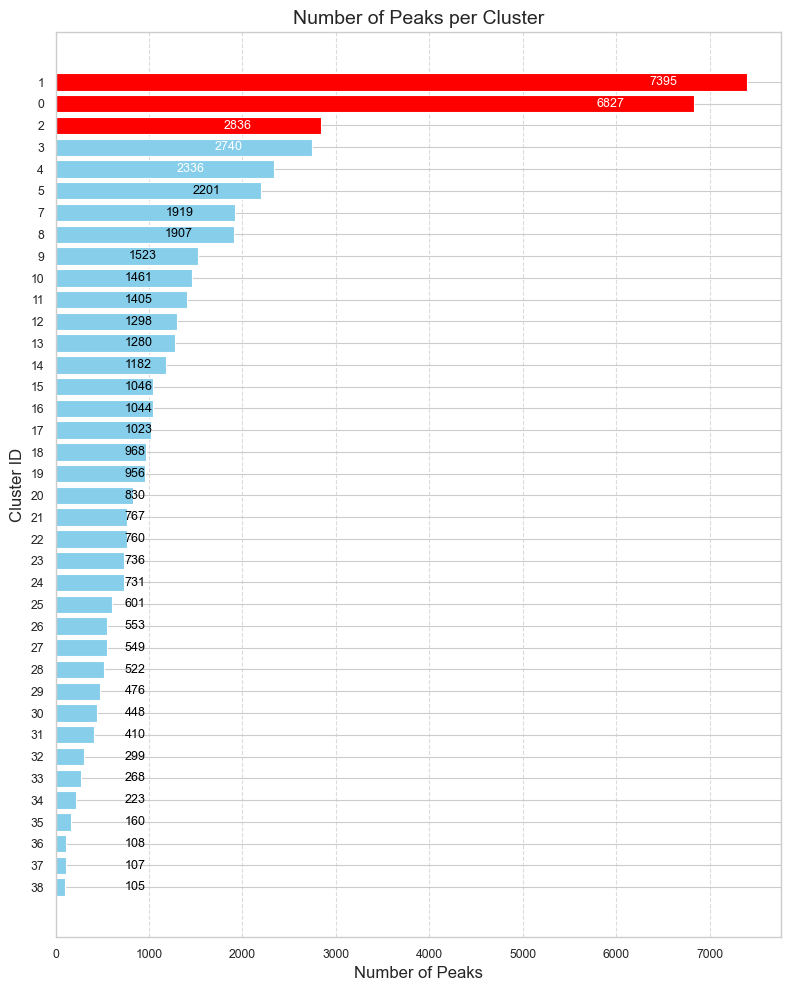

In [76]:
# Vertical bar plot sorted by count (descending)
fig_v, counts_v = plot_peaks_per_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    highlight_top=3,
    sort_by='count'
)

# Horizontal bar plot - better for many clusters
fig_h, counts_h = plot_peaks_per_cluster_horizontal(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    highlight_top=3,
    sort_by='count'
)

# To sort by cluster ID instead:
fig_by_id, counts_by_id = plot_peaks_per_cluster(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    sort_by='cluster'
)

In [80]:
# Define the specific order from your current plot
custom_cluster_order = [
    '1', '7', '22', '0', '11', '2', '17', '3', '8', '20', '10', '25', '27', '26', 
    '5', '30', '33', '12', '15', '19', '21', '9', '28', '23', '31', '4', '14', '24', 
    '29', '13', '32', '16', '38', '18', '35', '36', '37'
]

# Reverse the order to flip the y-axis
reversed_cluster_order = custom_cluster_order[::-1]

# Create the horizontal bar plot with custom ordering
fig, counts = plot_peaks_per_cluster_horizontal_ordered(
    peaks_pb_hvp_50k,
    cluster_key='leiden',
    custom_order=reversed_cluster_order,
    highlight_top=3,  # Highlight top 3 clusters by count
    figsize=(10, 12)  # Adjust figure size as needed
)

# Save the figure
fig.savefig('peak_cluster_counts_horizontal_ordered.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_1541021/2933795963.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


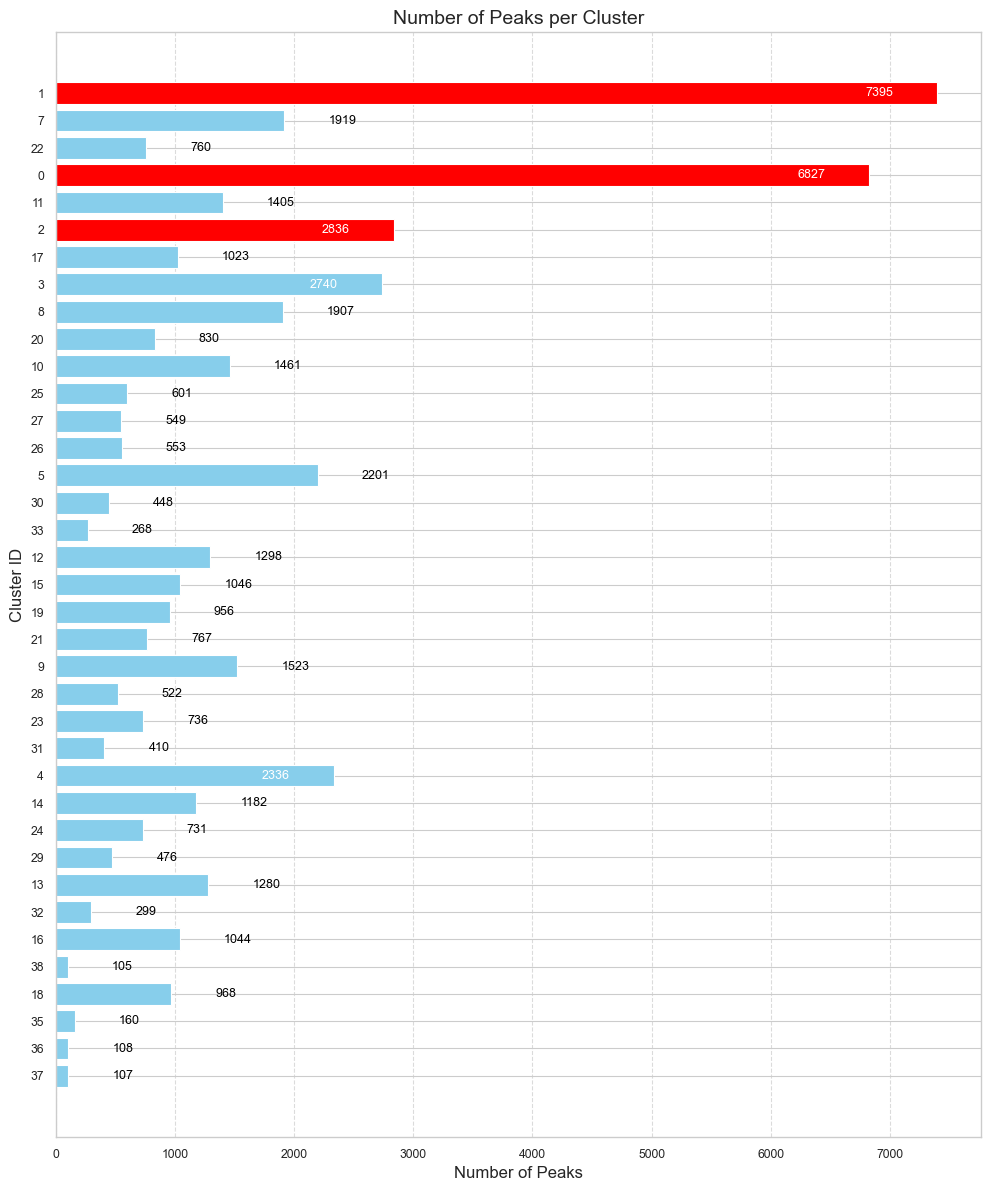

In [87]:
# Create a simple horizontal bar plot with the reversed ordering
fig, ax = plt.subplots(figsize=(8, 12))

# Count peaks per cluster
cluster_counts = peaks_pb_hvp_50k.obs['leiden'].value_counts()

# Reindex according to reversed order
ordered_counts = cluster_counts.reindex(reversed_cluster_order)

# Create the horizontal bar plot with gray bars
ax.barh(range(len(ordered_counts)), ordered_counts.values, color='gray')

# Set log scale for x-axis
ax.set_xscale('log')

# Set labels and remove grid
ax.set_ylabel('Cluster ID', fontsize=12)
ax.set_xlabel('Number of Peaks (log scale)', fontsize=12)
ax.set_title('Number of Peaks per Cluster', fontsize=14)
ax.set_yticks(range(len(ordered_counts)))
ax.set_yticklabels(ordered_counts.index)
ax.grid(False)  # Explicitly remove grid

plt.tight_layout()
plt.savefig('peak_cluster_counts_editable.pdf', 
            dpi=150, 
            bbox_inches='tight',
            format='pdf',
            transparent=True)

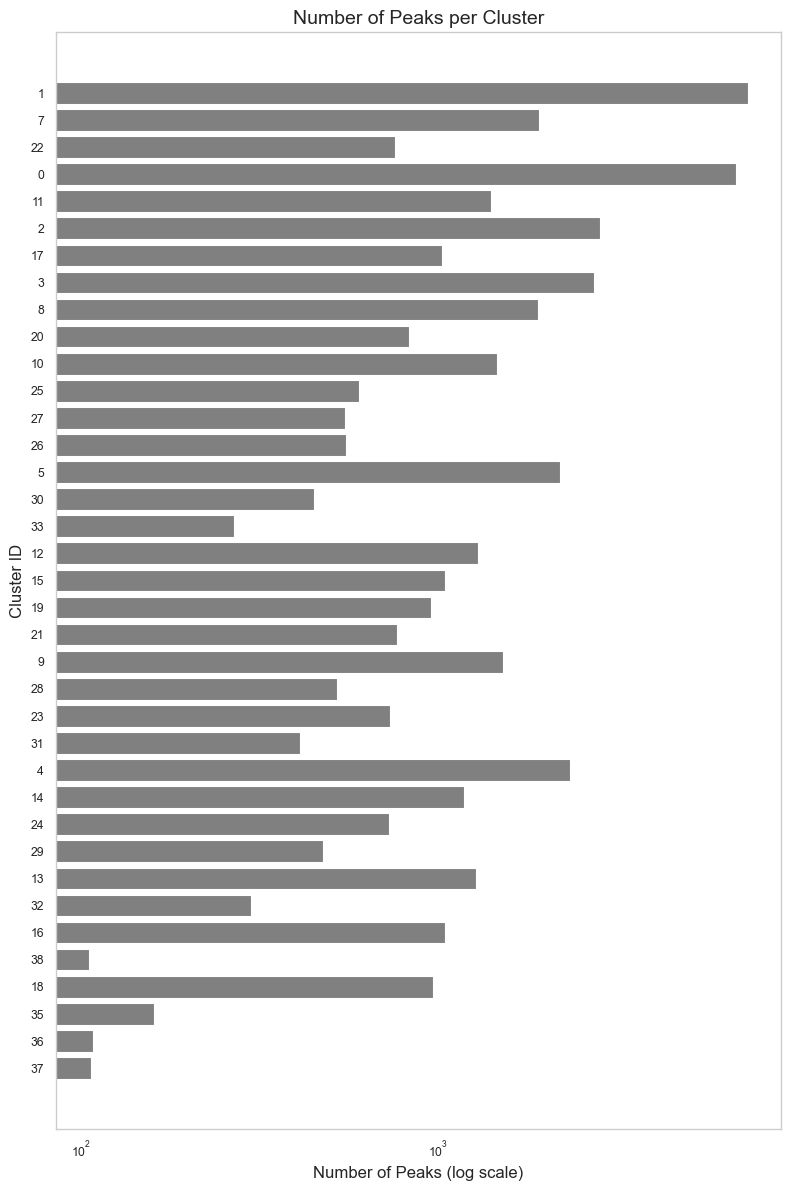

In [84]:
fig

### 1) number of regulatory programs (per celltype/timepoint) vs cell number

In [7]:
adata_rna.obs["annotation_ML_coarse"].value_counts()

annotation_ML_coarse
epidermis                      9496
neural_optic                   6730
midbrain_hindbrain_boundary    5525
neural_crest                   5270
spinal_cord                    5110
PSM                            4674
neural_floor_plate             4469
neural_posterior               3762
optic_cup                      3660
neurons                        3477
floor_plate                    3458
somites                        3434
tail_bud                       3374
pronephros                     3358
endocrine_pancreas             3075
heart_myocardium               2934
hindbrain                      2577
differentiating_neurons        2242
fast_muscle                    1996
pharyngeal_arches              1981
NMPs                           1904
endoderm                       1881
lateral_plate_mesoderm         1876
hematopoietic_vasculature      1625
muscle                         1342
neural_telencephalon           1277
hemangioblasts                 1177
hatchin

In [8]:
peaks_pb_hvp_50k.obs["celltype"].value_counts()

celltype
primordial_germ_cells          10517
epidermis                       3374
NMPs                            3310
hatching_gland                  3076
tail_bud                        2853
optic_cup                       2844
enteric_neurons                 2375
neural                          2325
fast_muscle                     2097
muscle                          1859
hematopoietic_vasculature       1306
notochord                       1224
hemangioblasts                  1166
PSM                             1031
endoderm                        1007
differentiating_neurons          899
heart_myocardium                 810
endocrine_pancreas               804
lateral_plate_mesoderm           757
neural_crest                     718
neural_telencephalon             715
pharyngeal_arches                699
pronephros                       686
midbrain_hindbrain_boundary      618
spinal_cord                      540
neural_optic                     478
neural_posterior             

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


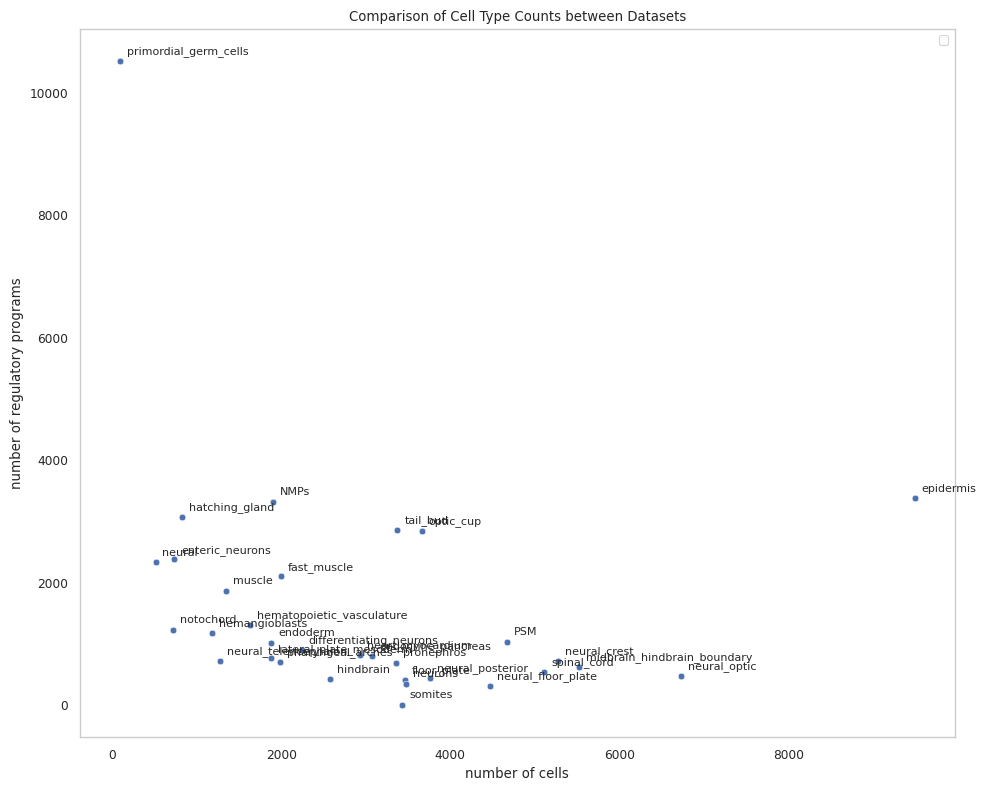

Correlation coefficient: -0.273


In [10]:
# Create DataFrames from the value_counts
df1 = pd.DataFrame(adata_rna.obs["annotation_ML_coarse"].value_counts()).reset_index()
df1.columns = ['celltype', 'n_cells']

df2 = pd.DataFrame(peaks_pb_hvp_50k.obs["celltype"].value_counts()).reset_index()
df2.columns = ['celltype', 'n_reg_programs']

# Merge the dataframes
merged_df = pd.merge(df1, df2, on='celltype', how='outer').fillna(0)

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=merged_df, x='n_cells', y='n_reg_programs')

# Add labels for points
for idx, row in merged_df.iterrows():
    plt.annotate(row['celltype'], 
                (row['n_cells'], row['n_reg_programs']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=8)

# Customize the plot
plt.title('Comparison of Cell Type Counts between Datasets')
plt.xlabel('number of cells')
plt.ylabel('number of regulatory programs')

# # Add a diagonal line for reference
# max_val = max(merged_df['n_cells'].max(), merged_df['n_reg_programs'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='1:1 line')

plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Optional: Print correlation coefficient
correlation = merged_df['n_cells'].corr(merged_df['n_reg_programs'])
print(f"Correlation coefficient: {correlation:.3f}")

In [11]:
# a color palette for the "coarse" grained celltype annotation ("annotation_ML_coarse")
cell_type_color_dict = {
    'NMPs': '#8dd3c7',
    'PSM': '#008080',
    'differentiating_neurons': '#bebada',
    'endocrine_pancreas': '#fb8072',
    'endoderm': '#80b1d3',
    'enteric_neurons': '#fdb462',
    'epidermis': '#b3de69',
    'fast_muscle': '#df4b9b',
    'floor_plate': '#d9d9d9',
    'hatching_gland': '#bc80bd',
    'heart_myocardium': '#ccebc5',
    'hemangioblasts': '#ffed6f',
    'hematopoietic_vasculature': '#e41a1c',
    'hindbrain': '#377eb8',
    'lateral_plate_mesoderm': '#4daf4a',
    'midbrain_hindbrain_boundary': '#984ea3',
    'muscle': '#ff7f00',
    'neural': '#e6ab02',
    'neural_crest': '#a65628',
    'neural_floor_plate': '#66a61e',
    'neural_optic': '#999999',
    'neural_posterior': '#393b7f',
    'neural_telencephalon': '#fdcdac',
    'neurons': '#cbd5e8',
    'notochord': '#f4cae4',
    'optic_cup': '#c0c000',
    'pharyngeal_arches': '#fff2ae',
    'primordial_germ_cells': '#f1e2cc',
    'pronephros': '#cccccc',
    'somites': '#1b9e77',
    'spinal_cord': '#d95f02',
    'tail_bud': '#7570b3'
}

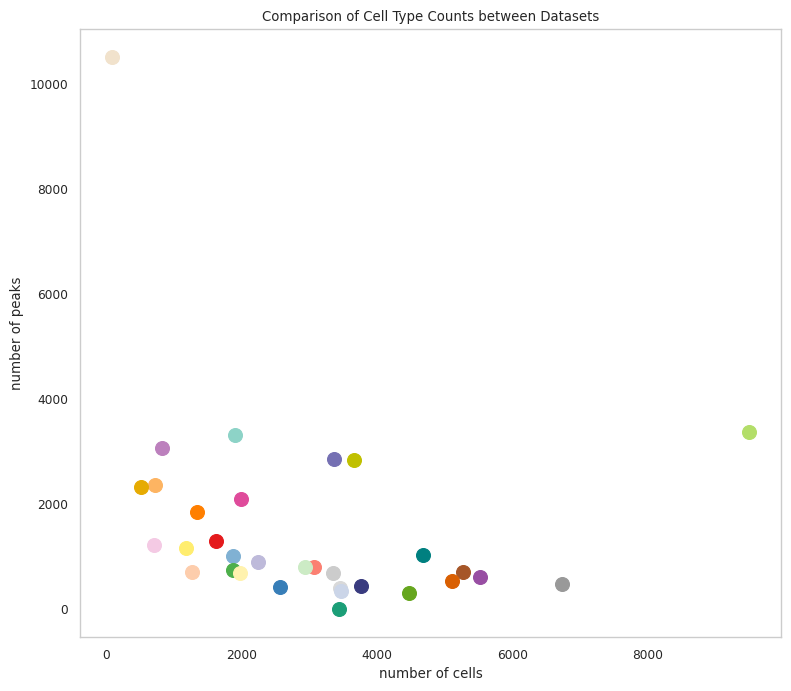

Correlation coefficient: -0.273


In [53]:
# Create DataFrames from the value_counts
df1 = pd.DataFrame(adata_rna.obs["annotation_ML_coarse"].value_counts()).reset_index()
df1.columns = ['celltype', 'n_cells']
df2 = pd.DataFrame(peaks_pb_hvp_50k.obs["celltype"].value_counts()).reset_index()
df2.columns = ['celltype', 'n_reg_programs']

# Merge the dataframes
merged_df = pd.merge(df1, df2, on='celltype', how='outer').fillna(0)

# Create the scatter plot
plt.figure(figsize=(8, 7))
# Create scatter plot with colors from dictionary
for idx, row in merged_df.iterrows():
    plt.scatter(row['n_cells'], row['n_reg_programs'], 
               color=cell_type_color_dict[row['celltype']], 
               label=row['celltype'], s=100)

# # Add labels for points
# for idx, row in merged_df.iterrows():
#     plt.annotate(row['celltype'], 
#                 (row['n_cells'], row['n_reg_programs']),
#                 xytext=(5, 5), 
#                 textcoords='offset points',
#                 fontsize=8)

# Customize the plot
plt.title('Comparison of Cell Type Counts between Datasets')
plt.xlabel('number of cells')
plt.ylabel('number of peaks')

plt.grid(False)
plt.tight_layout()

# Add legend (optional - might be crowded with many cell types)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(figpath + "scatter_n_cells_n_peaks_no_annot.pdf")
plt.show()

# Optional: Print correlation coefficient
correlation = merged_df['n_cells'].corr(merged_df['n_reg_programs'])
print(f"Correlation coefficient: {correlation:.3f}")

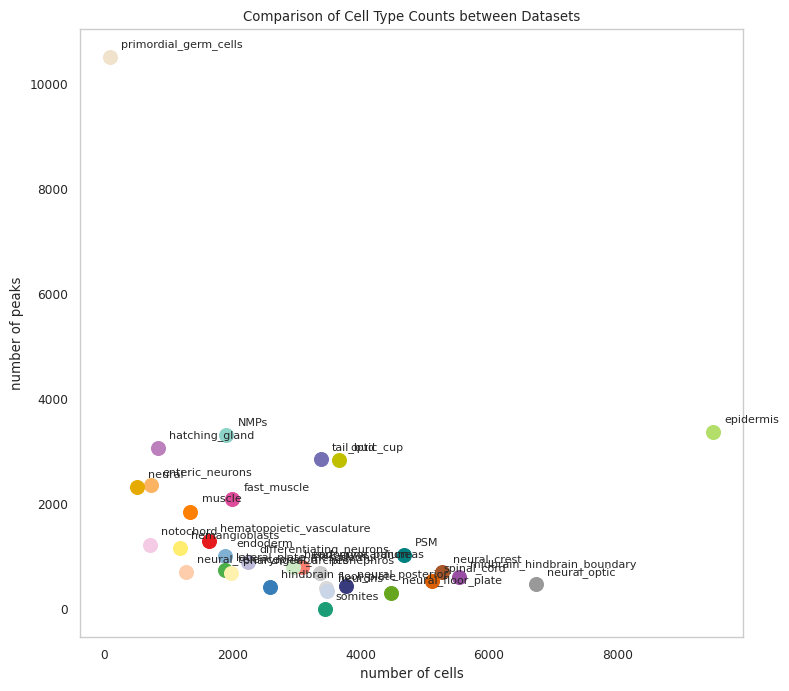

Correlation coefficient: -0.273


In [51]:
# Create the scatter plot
plt.figure(figsize=(8, 7))

# Create scatter plot with colors from dictionary
for idx, row in merged_df.iterrows():
    plt.scatter(row['n_cells'], row['n_reg_programs'], 
               color=cell_type_color_dict[row['celltype']], 
               label=row['celltype'], s=100)

# Add labels for points
for idx, row in merged_df.iterrows():
    plt.annotate(row['celltype'], 
                (row['n_cells'], row['n_reg_programs']),
                xytext=(8, 7), 
                textcoords='offset points',
                fontsize=8)

# Customize the plot
plt.title('Comparison of Cell Type Counts between Datasets')
plt.xlabel('number of cells')
plt.ylabel('number of peaks')

plt.grid(False)
plt.tight_layout()

# Add legend (optional - might be crowded with many cell types)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(figpath + "scatter_n_cells_n_peaks_no_lines.pdf")
plt.show()

# Optional: Print correlation coefficient
correlation = merged_df['n_cells'].corr(merged_df['n_reg_programs'])
print(f"Correlation coefficient: {correlation:.3f}")

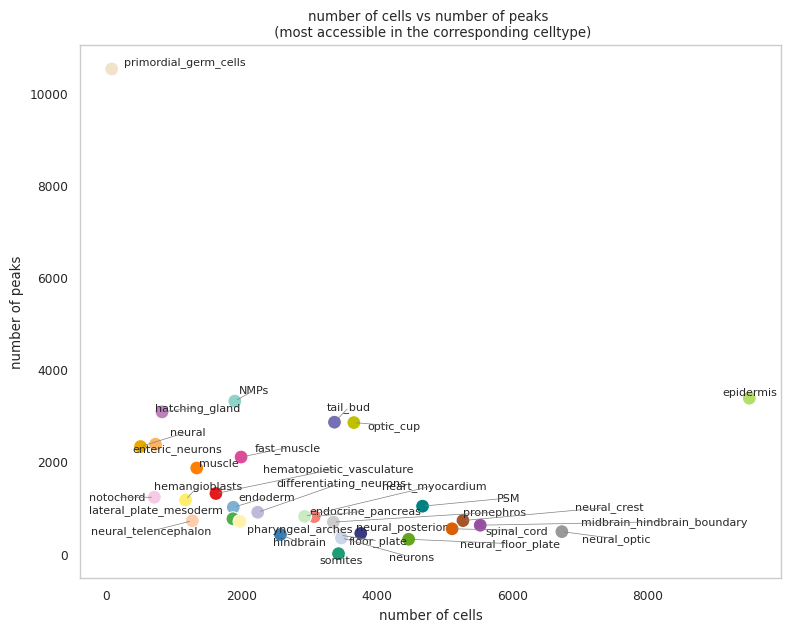

Correlation coefficient: -0.273


In [47]:
from adjustText import adjust_text

# Create DataFrames from the value_counts
df1 = pd.DataFrame(adata_rna.obs["annotation_ML_coarse"].value_counts()).reset_index()
df1.columns = ['celltype', 'n_cells']
df2 = pd.DataFrame(peaks_pb_hvp_50k.obs["celltype"].value_counts()).reset_index()
df2.columns = ['celltype', 'n_reg_programs']

# Merge the dataframes
merged_df = pd.merge(df1, df2, on='celltype', how='outer').fillna(0)

# Create the scatter plot
plt.figure(figsize=(8, 7))

# Create scatter plot with colors
scatter = sns.scatterplot(data=merged_df, 
                         x='n_cells', 
                         y='n_reg_programs',
                         hue='celltype',
                         palette=cell_type_color_dict, s=100)

# Create texts for adjustment
texts = []
for idx, row in merged_df.iterrows():
    texts.append(plt.text(row['n_cells'], row['n_reg_programs'], 
                         row['celltype'], 
                         fontsize=8))

# Adjust text positions to minimize overlap
adjust_text(texts, 
           arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
           expand_points=(1.5, 1.5))

# Customize the plot
plt.title('number of cells vs number of peaks \n (most accessible in the corresponding celltype)')
plt.xlabel('number of cells')
plt.ylabel('number of peaks')
plt.grid(False)
plt.tight_layout()

# Remove legend as we have labels
plt.legend([],[], frameon=False)
plt.savefig(figpath + "scatter_n_cells_n_peaks.pdf")
plt.savefig(figpath + "scatter_n_cells_n_peaks.png")
plt.show()

# Optional: Print correlation coefficient
correlation = merged_df['n_cells'].corr(merged_df['n_reg_programs'])
print(f"Correlation coefficient: {correlation:.3f}")

In [45]:
# First, let's create a cross-tabulation of leiden clusters and celltypes
cluster_celltype_counts = pd.crosstab(
    peaks_pb_hvp_50k.obs['leiden'], 
    peaks_pb_hvp_50k.obs['celltype']
)

# For each leiden cluster, find the most abundant celltype
leiden_to_celltype = {}
for cluster in cluster_celltype_counts.index:
    most_abundant_celltype = cluster_celltype_counts.loc[cluster].idxmax()
    leiden_to_celltype[cluster] = most_abundant_celltype

# Convert this to a DataFrame if you want to see it clearly
mapping_df = pd.DataFrame.from_dict(leiden_to_celltype, orient='index', columns=['most_abundant_celltype'])

# Now, to get the count of leiden clusters per celltype
celltype_cluster_counts = pd.Series(leiden_to_celltype).value_counts()

# Convert to DataFrame for better visualization
final_df = pd.DataFrame(celltype_cluster_counts).reset_index()
final_df.columns = ['celltype', 'number_of_clusters']

# Display results
print("Mapping of leiden clusters to most abundant celltype:")
print(mapping_df.head())
print("\nNumber of leiden clusters per celltype:")
print(final_df.head())

Mapping of leiden clusters to most abundant celltype:
        most_abundant_celltype
0                     tail_bud
1                    optic_cup
2        primordial_germ_cells
3  midbrain_hindbrain_boundary
4                         NMPs

Number of leiden clusters per celltype:
                celltype  number_of_clusters
0  primordial_germ_cells                  15
1                   NMPs                   4
2              epidermis                   3
3                 neural                   3
4         hatching_gland                   2


In [44]:
# First create cross-tabulation and convert to proportions
cluster_celltype_counts = pd.crosstab(
    peaks_pb_hvp_50k.obs['leiden'], 
    peaks_pb_hvp_50k.obs['celltype']
)

# Calculate proportions
cluster_celltype_props = cluster_celltype_counts.div(cluster_celltype_counts.sum(axis=1), axis=0)

# Create a dictionary or dataframe to store top 2 celltypes and their fractions
top_2_celltypes = {}

for cluster in cluster_celltype_counts.index:
    # Get the sorted series of proportions for this cluster
    cluster_props = cluster_celltype_props.loc[cluster].sort_values(ascending=False)
    
    # Get top 2 celltypes and their proportions
    top_2 = cluster_props.head(2)
    
    # Store both celltype and proportion
    top_2_celltypes[cluster] = {
        'celltype1': top_2.index[0],
        'fraction1': round(top_2.values[0], 3),
        'celltype2': top_2.index[1],
        'fraction2': round(top_2.values[1], 3)
    }

# Convert to DataFrame for easy viewing
result_df = pd.DataFrame.from_dict(top_2_celltypes, orient='index')

# Sort by leiden cluster if they're numbered
result_df = result_df.sort_index()

print("Top 2 celltypes and their fractions for each leiden cluster:")
print(result_df.head())

Top 2 celltypes and their fractions for each leiden cluster:
                celltype1  fraction1              celltype2  fraction2
0                tail_bud      0.363  primordial_germ_cells      0.081
1               optic_cup      0.313  primordial_germ_cells      0.078
10  primordial_germ_cells      0.755                   NMPs      0.055
11            fast_muscle      0.518                 muscle      0.352
12  primordial_germ_cells      0.792              epidermis      0.055


<Figure size 800x700 with 0 Axes>

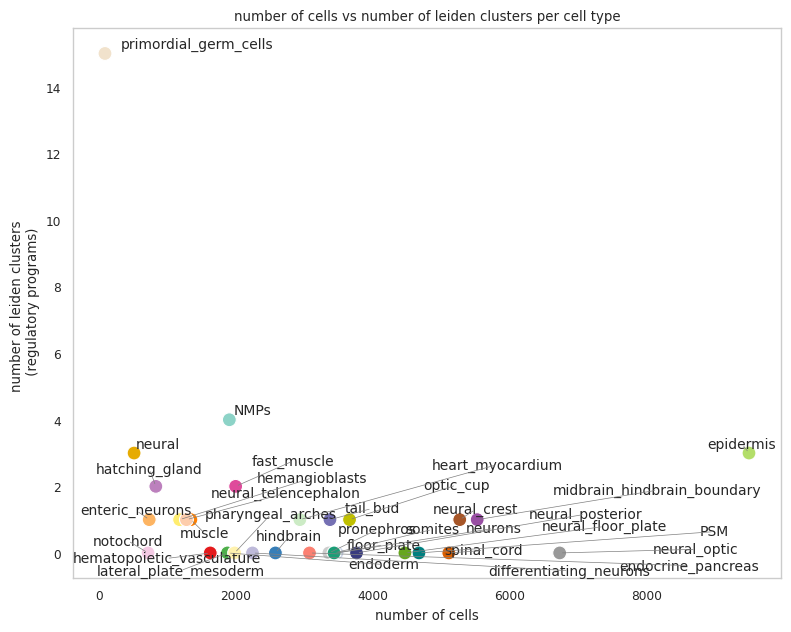

Correlation coefficient: -0.249


In [55]:
# Create DataFrame with cell counts from adata_rna
df1 = pd.DataFrame(adata_rna.obs["annotation_ML_coarse"].value_counts()).reset_index()
df1.columns = ['celltype', 'n_cells']

# Use the cluster counts from final_df
cluster_counts = final_df.copy()
cluster_counts.columns = ['celltype', 'n_clusters']

# Merge the two dataframes
merged_df = pd.merge(df1, cluster_counts, on='celltype', how='outer')

# Fill NaN values with 0 for celltypes that don't have any clusters
merged_df = merged_df.fillna(0)

# Create the scatter plot
plt.figure(figsize=(8, 7))

# Create scatter plot with colors
scatter = sns.scatterplot(data=merged_df, 
                         x='n_cells', 
                         y='n_clusters',
                         hue='celltype',
                         palette=cell_type_color_dict,
                         s=100)

# Add labels for each point
texts = []
for idx, row in merged_df.iterrows():
    texts.append(plt.text(row['n_cells'], row['n_clusters'], 
                         row['celltype'], 
                         fontsize=10))

# Adjust text positions to minimize overlap
adjust_text(texts, 
           arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
           expand_points=(1.5, 1.5))

# Customize the plot
plt.title('number of cells vs number of leiden clusters per cell type')
plt.xlabel('number of cells')
plt.ylabel('number of leiden clusters \n (regulatory programs)')
plt.grid(False)
plt.tight_layout()

# Remove legend as we have labels
plt.legend([],[], frameon=False)
plt.savefig(figpath + "scatter_n_cells_n_reg_programs.pdf")
plt.show()

# Calculate correlation
correlation = merged_df['n_cells'].corr(merged_df['n_clusters'])
print(f"Correlation coefficient: {correlation:.3f}")

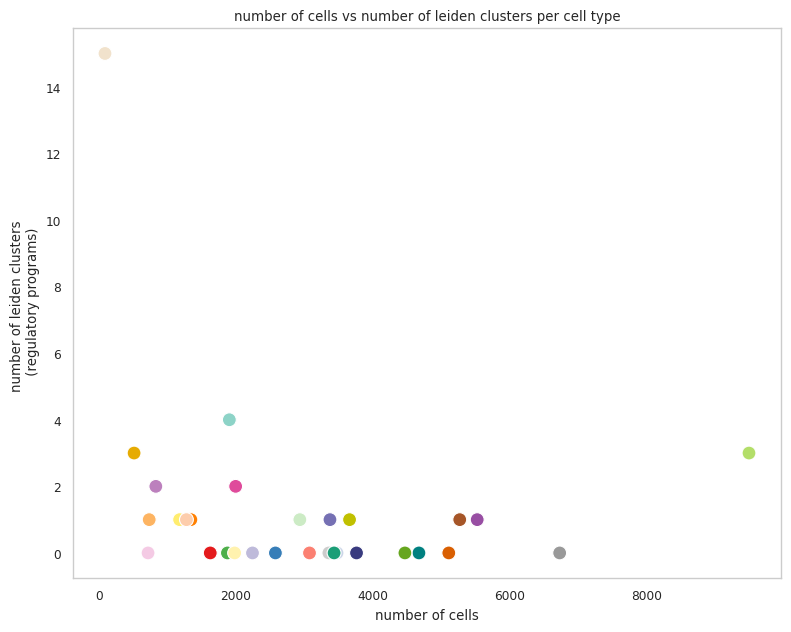

Correlation coefficient: -0.249


In [56]:
# Create the scatter plot
plt.figure(figsize=(8, 7))

# Create scatter plot with colors
scatter = sns.scatterplot(data=merged_df, 
                         x='n_cells', 
                         y='n_clusters',
                         hue='celltype',
                         palette=cell_type_color_dict,
                         s=100)

# # Add labels for each point
# texts = []
# for idx, row in merged_df.iterrows():
#     texts.append(plt.text(row['n_cells'], row['n_clusters'], 
#                          row['celltype'], 
#                          fontsize=10))

# # Adjust text positions to minimize overlap
# adjust_text(texts, 
#            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
#            expand_points=(1.5, 1.5))

# Customize the plot
plt.title('number of cells vs number of leiden clusters per cell type')
plt.xlabel('number of cells')
plt.ylabel('number of leiden clusters \n (regulatory programs)')
plt.grid(False)
plt.tight_layout()

# Remove legend as we have labels
plt.legend([],[], frameon=False)
plt.savefig(figpath + "scatter_n_cells_n_reg_programs_no_annot.pdf")
plt.show()

# Calculate correlation
correlation = merged_df['n_cells'].corr(merged_df['n_clusters'])
print(f"Correlation coefficient: {correlation:.3f}")

### 2) fraction of celltypes per "regulatory program"

### 3) fraction of chromosomes per "regulatory program"